In [1]:
#intallkmodes.kmodes 

!pip install kmodes




[notice] A new release of pip available: 22.3.1 -> 25.3
[notice] To update, run: C:\Users\el_bostan\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline
import os
df = pd.read_csv("C:\\Users\\el_bostan\\Desktop\\مشروع FCAI\\heart+disease\\cardio_processed.csv")

from kmodes.kmodes import KModes

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

# supress warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50,2,168,62,110,80,1,1,0,0,1,0
1,1,55,1,156,85,140,90,3,1,0,0,1,1
2,2,52,1,165,64,130,70,3,1,0,0,0,1
3,3,48,2,169,82,150,100,1,1,0,0,1,1
4,4,48,1,156,56,100,60,1,1,0,0,0,0


Cleaning Data

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   id           70000 non-null  int64
 1   age          70000 non-null  int64
 2   gender       70000 non-null  int64
 3   height       70000 non-null  int64
 4   weight       70000 non-null  int64
 5   ap_hi        70000 non-null  int64
 6   ap_lo        70000 non-null  int64
 7   cholesterol  70000 non-null  int64
 8   gluc         70000 non-null  int64
 9   smoke        70000 non-null  int64
 10  alco         70000 non-null  int64
 11  active       70000 non-null  int64
 12  cardio       70000 non-null  int64
dtypes: int64(13)
memory usage: 6.9 MB


In [5]:
df.isnull().values.any()

np.False_

In [6]:
#removing Outliers
# Let's remove weights and heights, that fall below 2.5% or above 97.5% of a given range.
df.drop(df[(df['height'] > df['height'].quantile(0.975)) | (df['height'] < df['height'].quantile(0.025))].index,inplace=True)
df.drop(df[(df['weight'] > df['weight'].quantile(0.975)) | (df['weight'] < df['weight'].quantile(0.025))].index,inplace=True)

In [7]:
#In addition, in some cases diastolic pressure is higher than systolic, which is also  incorrect. How many records are inaccurate in terms of blood pressure?
print("Diastilic pressure is higher than systolic one in {0} cases".format(df[df['ap_lo']> df['ap_hi']].shape[0]))

Diastilic pressure is higher than systolic one in 1082 cases


In [8]:
df.drop(df[(df['ap_hi'] > df['ap_hi'].quantile(0.975)) | (df['ap_hi'] < df['ap_hi'].quantile(0.025))].index,inplace=True)
df.drop(df[(df['ap_lo'] > df['ap_lo'].quantile(0.975)) | (df['ap_lo'] < df['ap_lo'].quantile(0.025))].index,inplace=True)

In [9]:
#after removing outliers
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,60145.000000,60145.000000,60145.000000,60145.000000,60145.000000,60145.000000,60145.000000,60145.000000,60145.000000,60145.000000,60145.000000,60145.000000,60145.000000
mean,49895.586000,53.339064,1.347294,164.554693,73.427351,125.770737,81.046587,1.350968,1.220218,0.085626,0.051891,0.803658,0.488253
std,28840.654627,6.746942,0.476114,6.830067,11.616460,13.761536,8.239114,0.670096,0.567595,0.279814,0.221809,0.397234,0.499866
min,0.000000,30.000000,1.000000,150.000000,52.000000,100.000000,60.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,24866.000000,48.000000,1.000000,160.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,49903.000000,54.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74746.000000,58.000000,2.000000,169.000000,80.000000,135.000000,90.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,65.000000,2.000000,180.000000,106.000000,163.000000,100.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


 Transforming Data

In [10]:
df.drop(['id'], axis='columns', inplace=True)

In [11]:
# age_bin in quinquenium 5 years spam
df['age_bin'] = pd.cut(df['age'], [0,20,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100], 
                              labels=['0-20', '20-30', '30-35', '35-40','40-45','45-50','50-55','55-60','60-65','65-70','70-75','75-80','80-85','85-90','90-95','95-100'])

Transforming the column bmi in Body Mass Index Classes (1 to 6)

Add Columns MAP_Class, BMI_Class, years and age_bin 

In [12]:
# Adding Body Mass Index
df['bmi'] = df['weight']/((df['height']/100)**2)

In [13]:
# transforming the column bmi in Body Mass Index Classes (1 to 6)
rating = []
for row in df['bmi']:
    if row < 18.5 :    rating.append(1) #UnderWeight
    elif row > 18.5 and row  < 24.9:   rating.append(2)#NormalWeight
    elif row > 24.9 and row < 29.9:  rating.append(3)#OverWeight
    elif row > 29.9 and row < 34.9:  rating.append(4)#ClassObesity_1
    elif row > 34.9 and row < 39.9:  rating.append(5)#ClassObesity_2
    elif row > 39.9 and row < 49.9:  rating.append(6)#ClassObesity_3
    elif row > 49.9:  rating.append('Error')
        
    else:           rating.append('Not_Rated')

In [14]:
# inserting Column
df['BMI_Class'] = rating

In [15]:
# general distribuition
df["BMI_Class"].value_counts(normalize=True)

BMI_Class
3    0.391820
2    0.361909
4    0.179150
5    0.055815
6    0.009194
1    0.002112
Name: proportion, dtype: float64

Creating the column MAP
Mean Arterial Pressure (MAP) = 2 Diastollic Blood Pressure + Sistolic Blood Pressure / 3

The overall blood pressure as measured in the brachial artery is maintained by the cardiac output and the total peripheral resistance (TPR) to flow. The mean arterial pressure (MAP) is calculated by the formula:

In [16]:
# creating a Column for MAP
df['MAP'] = ((2* df['ap_lo']) + df['ap_hi']) / 3

In [17]:
#Creating Classes for MAP
map_values = []
for row in df['MAP']:
    if row < 69.9:    map_values.append(1) #Low
    elif row > 70 and row  < 79.9:   map_values.append(2)#Normal
    elif row > 79.9 and row < 89.9:  map_values.append(3)#Normal
    elif row > 89.9 and row < 99.9:  map_values.append(4)#Normal
    elif row > 99.9 and row < 109.9:  map_values.append(5)#High
    elif row > 109.9 and row < 119.9:  map_values.append(6)#Normal
    elif row > 119.9:  map_values.append(7)
        
    else:           map_values.append('Not_Rated')

In [18]:
#inserting MAP_Class Column
df['MAP_Class'] = map_values

Reordering Columns

In [19]:
#Reordering Columns
df= df[["gender","height","weight","bmi","ap_hi","ap_lo","MAP","age","age_bin","BMI_Class","MAP_Class","cholesterol","gluc","smoke","active","cardio"]]
df.head()

,gender,height,weight,bmi,ap_hi,ap_lo,MAP,age,age_bin,BMI_Class,MAP_Class,cholesterol,gluc,smoke,active,cardio
0,2,168,62,21.967120,110,80,90.000000,50,45-50,2,4,1,1,0,1,0
1,1,156,85,34.927679,140,90,106.666667,55,50-55,5,5,3,1,0,1,1
2,1,165,64,23.507805,130,70,90.000000,52,50-55,2,4,3,1,0,0,1
3,2,169,82,28.710479,150,100,116.666667,48,45-50,3,6,1,1,0,1,1
4,1,156,56,23.011177,100,60,73.333333,48,45-50,2,2,1,1,0,0,0


Data Analize and Preparation

In [20]:
# only Categorical Data Columns DataFrame
df_cat = df[["gender","age_bin","BMI_Class","MAP_Class","cholesterol","gluc","smoke","active","cardio",]]

In [21]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
df_cat = df_cat.apply(le.fit_transform)
df_cat.head()

,gender,age_bin,BMI_Class,MAP_Class,cholesterol,gluc,smoke,active,cardio
0,1,3,1,2,0,0,0,1,0
1,0,4,4,3,2,0,0,1,1
2,0,4,1,2,2,0,0,0,1
3,1,3,2,4,0,0,0,1,1
4,0,3,1,0,0,0,0,0,0


In [22]:
df_male = df_cat.query("gender == 0")
df_female = df_cat.query("gender == 1")
df_male.head()

,gender,age_bin,BMI_Class,MAP_Class,cholesterol,gluc,smoke,active,cardio
1,0,4,4,3,2,0,0,1,1
2,0,4,1,2,2,0,0,0,1
4,0,3,1,0,0,0,0,0,0
5,0,5,2,2,1,1,0,0,0
6,0,6,4,2,2,0,0,1,0


In [23]:
df_female.head()

,gender,age_bin,BMI_Class,MAP_Class,cholesterol,gluc,smoke,active,cardio
0,1,3,1,2,0,0,0,1,0
3,1,3,2,4,0,0,0,1,1
7,1,6,3,3,2,2,0,1,1
11,1,4,1,2,0,0,0,1,0
12,1,2,1,2,0,0,0,0,0


MAP Classes

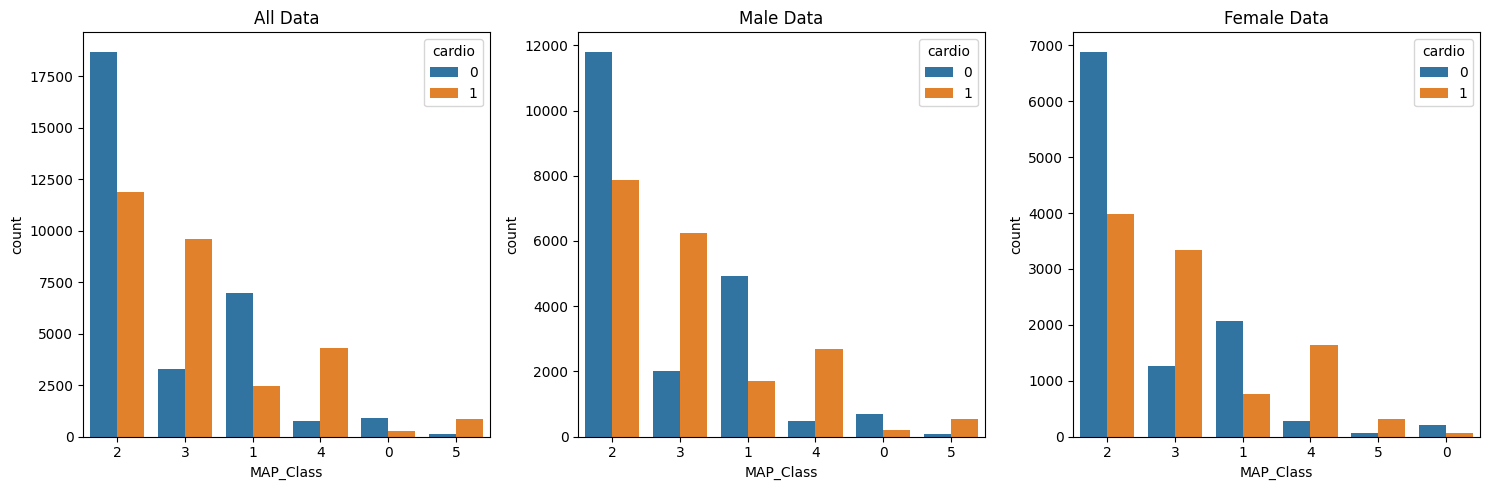

All the values are similar


In [24]:
f, axs = plt.subplots(1,3,figsize = (15,5))
sns.countplot(x=df_cat['MAP_Class'],order=df_cat['MAP_Class'].value_counts().index,hue=df_cat['cardio'],ax=axs[0])
sns.countplot(x=df_male['MAP_Class'],order=df_male['MAP_Class'].value_counts().index,hue=df_male['cardio'],ax=axs[1])
sns.countplot(x=df_female['MAP_Class'],order=df_female['MAP_Class'].value_counts().index,hue=df_female['cardio'],ax=axs[2])

axs[0].set_title('All Data')
axs[1].set_title('Male Data')
axs[2].set_title('Female Data')
plt.tight_layout()
plt.show()
print("All the values are similar")

BMI Classes

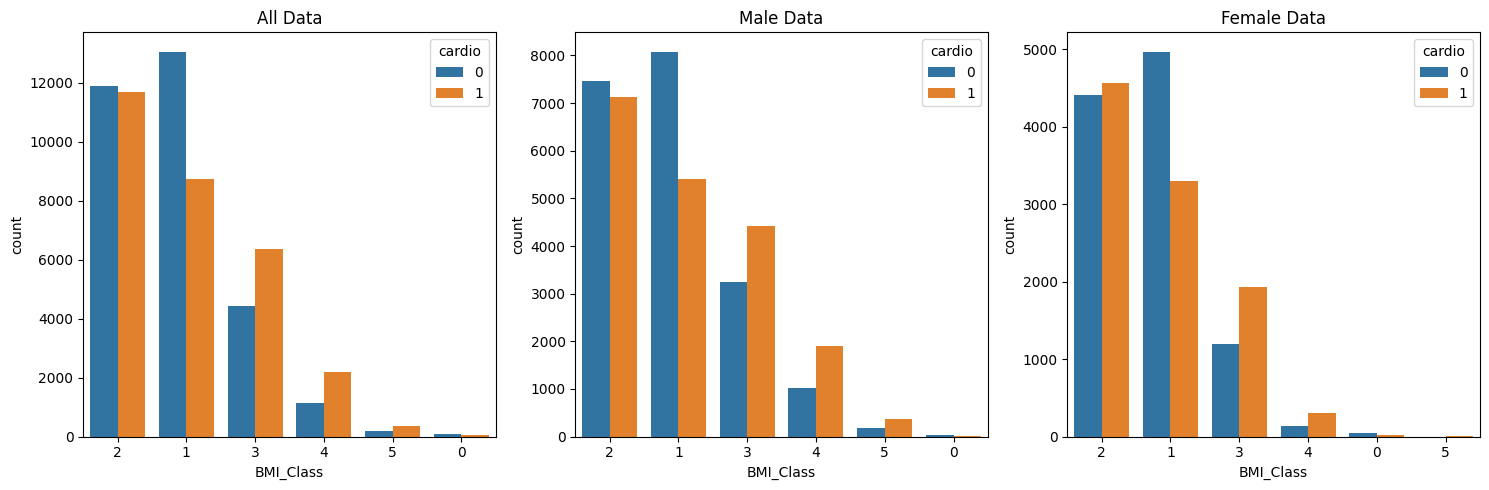

The BMI Classes for All data, Male and Female are very similar BUT the BMI_Class = 2 for Female data is slightly differen


In [25]:
f, axs = plt.subplots(1,3,figsize = (15,5))
sns.countplot(x=df_cat['BMI_Class'],order=df_cat['BMI_Class'].value_counts().index,hue=df_cat['cardio'],ax=axs[0])
sns.countplot(x=df_male['BMI_Class'],order=df_male['BMI_Class'].value_counts().index,hue=df_male['cardio'],ax=axs[1])
sns.countplot(x=df_female['BMI_Class'],order=df_female['BMI_Class'].value_counts().index,hue=df_female['cardio'],ax=axs[2])

axs[0].set_title('All Data')
axs[1].set_title('Male Data')
axs[2].set_title('Female Data')
plt.tight_layout()
plt.show()
print("The BMI Classes for All data, Male and Female are very similar BUT the BMI_Class = 2 for Female data is slightly differen")

Glucose

In [26]:
#f, axs = plt.subplots(1,3,figsize = (15,5))
sns.countplot(x=df_cat['gluc'],order=df_cat['gluc'].value_counts().index,hue=df_cat['cardio'],ax=axs[0])
sns.countplot(x=df_male['gluc'],order=df_male['gluc'].value_counts().index,hue=df_male['cardio'],ax=axs[1])
sns.countplot(x=df_female['gluc'],order=df_female['gluc'].value_counts().index,hue=df_female['cardio'],ax=axs[2])

axs[0].set_title('All Data')
axs[1].set_title('Male Data')
axs[2].set_title('Female Data')
plt.tight_layout()
plt.show()
print("All the values are similar")

<Figure size 640x480 with 0 Axes>

All the values are similar


Cholesterol

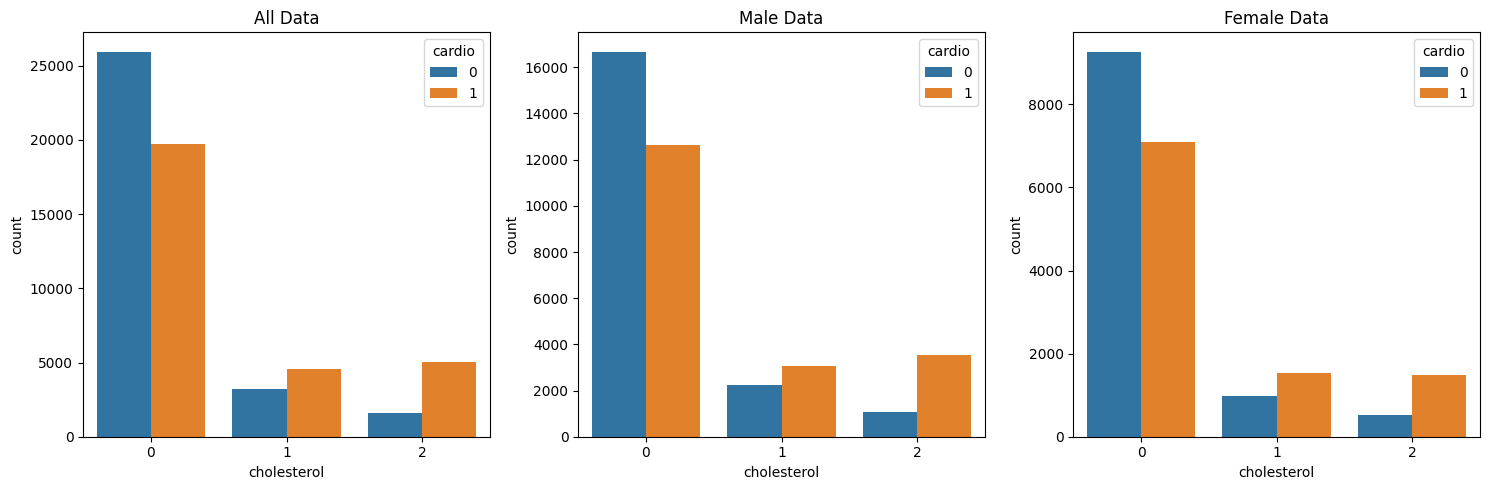

All the values are similar


In [27]:
f, axs = plt.subplots(1,3,figsize = (15,5))
sns.countplot(x=df_cat['cholesterol'],order=df_cat['cholesterol'].value_counts().index,hue=df_cat['cardio'],ax=axs[0])
sns.countplot(x=df_male['cholesterol'],order=df_male['cholesterol'].value_counts().index,hue=df_male['cardio'],ax=axs[1])
sns.countplot(x=df_female['cholesterol'],order=df_female['cholesterol'].value_counts().index,hue=df_female['cardio'],ax=axs[2])

axs[0].set_title('All Data')
axs[1].set_title('Male Data')
axs[2].set_title('Female Data')
plt.tight_layout()
plt.show()
print("All the values are similar")

Smoke

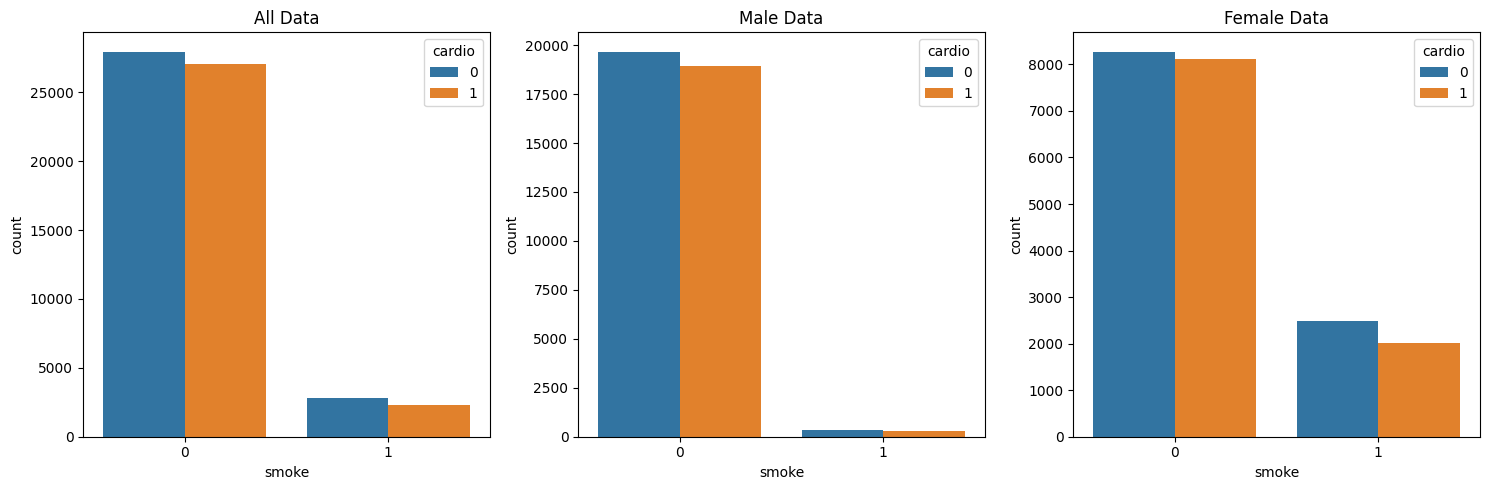

The value is high for Female data when smoke is 1


In [28]:
f, axs = plt.subplots(1,3,figsize = (15,5))
sns.countplot(x=df_cat['smoke'],order=df_cat['smoke'].value_counts().index,hue=df_cat['cardio'],ax=axs[0])
sns.countplot(x=df_male['smoke'],order=df_male['smoke'].value_counts().index,hue=df_male['cardio'],ax=axs[1])
sns.countplot(x=df_female['smoke'],order=df_female['smoke'].value_counts().index,hue=df_female['cardio'],ax=axs[2])

axs[0].set_title('All Data')
axs[1].set_title('Male Data')
axs[2].set_title('Female Data')
plt.tight_layout()
plt.show()
print("The value is high for Female data when smoke is 1")

Active

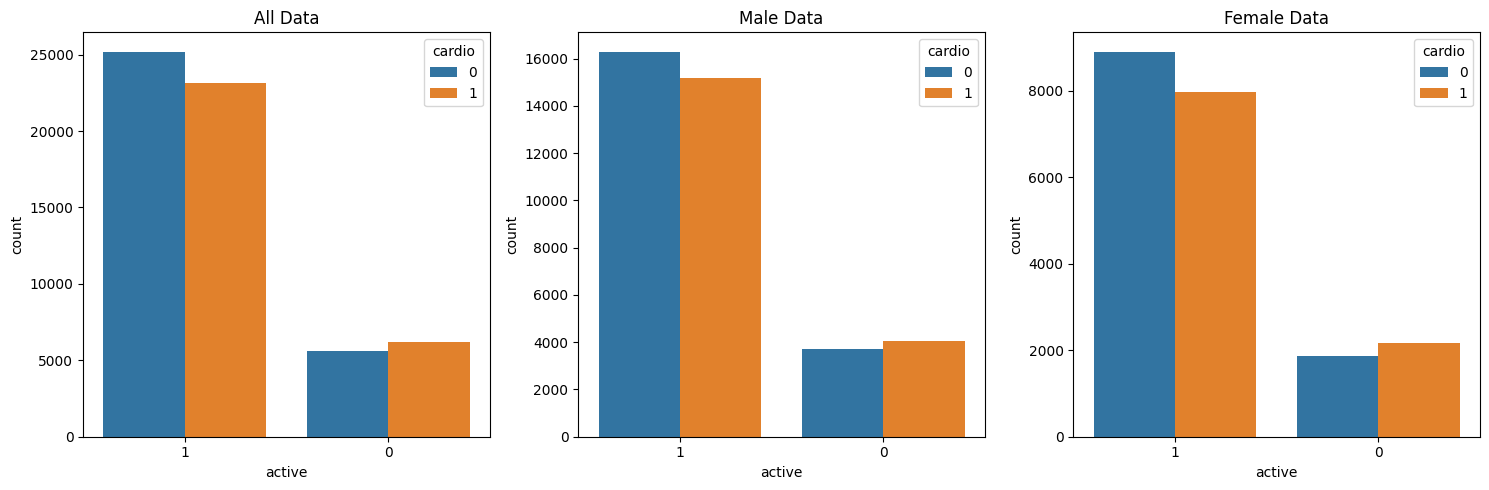

All the values are similar


In [29]:
f, axs = plt.subplots(1,3,figsize = (15,5))
sns.countplot(x=df_cat['active'],order=df_cat['active'].value_counts().index,hue=df_cat['cardio'],ax=axs[0])
sns.countplot(x=df_male['active'],order=df_male['active'].value_counts().index,hue=df_male['cardio'],ax=axs[1])
sns.countplot(x=df_female['active'],order=df_female['active'].value_counts().index,hue=df_female['cardio'],ax=axs[2])

axs[0].set_title('All Data')
axs[1].set_title('Male Data')
axs[2].set_title('Female Data')
plt.tight_layout()
plt.show()
print("All the values are similar")

 Age

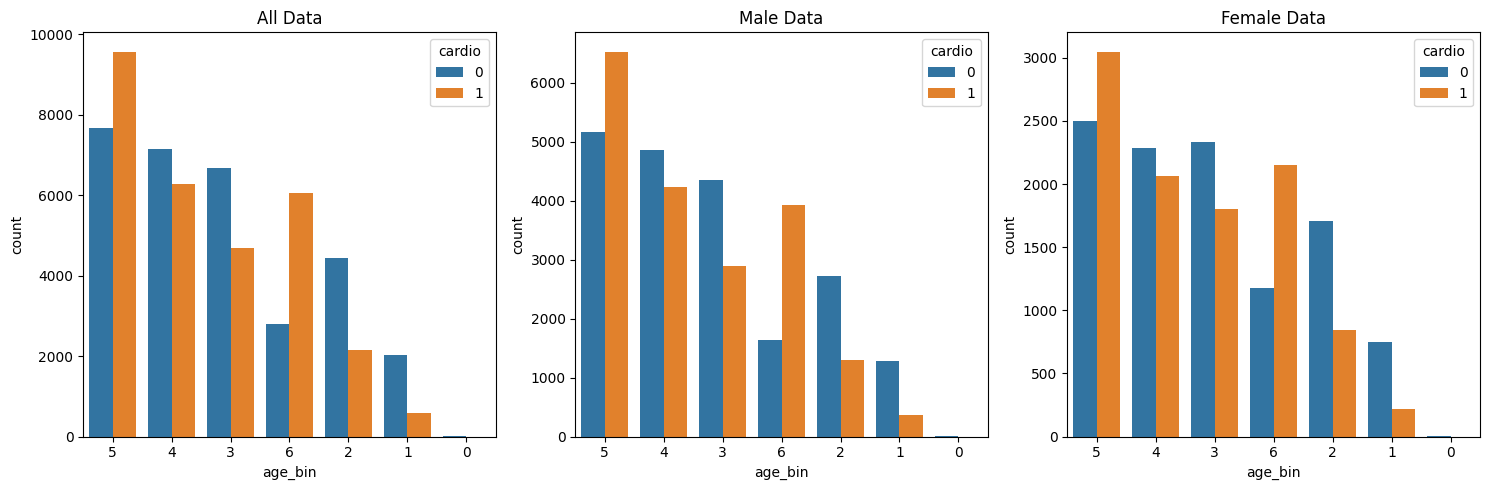

The datas are similar BUT in age_bin 6 (45-50 years) the values are very different


In [30]:
f, axs = plt.subplots(1,3,figsize = (15,5))
sns.countplot(x=df_cat['age_bin'],order=df_cat['age_bin'].value_counts().index,hue=df_cat['cardio'],ax=axs[0])
sns.countplot(x=df_male['age_bin'],order=df_male['age_bin'].value_counts().index,hue=df_male['cardio'],ax=axs[1])
sns.countplot(x=df_female['age_bin'],order=df_female['age_bin'].value_counts().index,hue=df_female['cardio'],ax=axs[2])

axs[0].set_title('All Data')
axs[1].set_title('Male Data')
axs[2].set_title('Female Data')
plt.tight_layout()
plt.show()
print("The datas are similar BUT in age_bin 6 (45-50 years) the values are very different")

KModes Analisys

In [31]:
df_male.head()

,gender,age_bin,BMI_Class,MAP_Class,cholesterol,gluc,smoke,active,cardio
1,0,4,4,3,2,0,0,1,1
2,0,4,1,2,2,0,0,0,1
4,0,3,1,0,0,0,0,0,0
5,0,5,2,2,1,1,0,0,0
6,0,6,4,2,2,0,0,1,0


In [32]:
df_female.head()

,gender,age_bin,BMI_Class,MAP_Class,cholesterol,gluc,smoke,active,cardio
0,1,3,1,2,0,0,0,1,0
3,1,3,2,4,0,0,0,1,1
7,1,6,3,3,2,2,0,1,1
11,1,4,1,2,0,0,0,1,0
12,1,2,1,2,0,0,0,0,0


Elbow Curve Method

For All Data

In [33]:
# Elbow curve to find optimal K in Huang init
cost = []
K = range(1,6)
for num_clusters in list(K):
    kmode = KModes(n_clusters=num_clusters, init = "Huang", n_init = 5, verbose=0)
    kmode.fit_predict(df_cat)
    cost.append(kmode.cost_)
    
plt.plot(K, cost, 'bx-')
plt.xlabel('No. of clusters')
plt.ylabel('Cost')
plt.title('Elbow Method For Optimal k')
plt.show()

KeyboardInterrupt: 

For Male Data

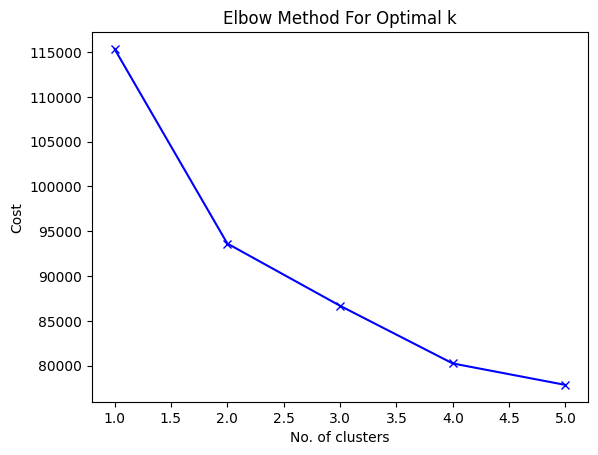

The best number os clusters for male Data in Huang Init is 2


In [ ]:
# Elbow curve to find optimal K in Huang
cost = []
K = range(1,6)
for num_clusters in list(K):
    kmode = KModes(n_clusters=num_clusters, init = "Huang", n_init = 5, verbose=0)
    kmode.fit_predict(df_male)
    cost.append(kmode.cost_)
    
plt.plot(K, cost, 'bx-')
plt.xlabel('No. of clusters')
plt.ylabel('Cost')
plt.title('Elbow Method For Optimal k')
plt.show()
print("The best number os clusters for male Data in Huang Init is 2")

For Female Data

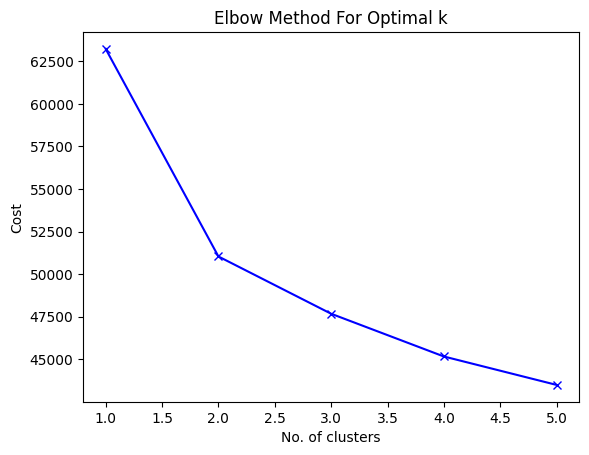

The best number of clusters for female data is 2
The best number of Clusters for All Data, Male and Female Data is 2 Clusters


In [ ]:
# Elbow curve to find optimal K
cost = []
K = range(1,6)
for num_clusters in list(K):
    kmode = KModes(n_clusters=num_clusters, init = "Huang", n_init = 5, verbose=0)
    kmode.fit_predict(df_female)
    cost.append(kmode.cost_)
    
plt.plot(K, cost, 'bx-')
plt.xlabel('No. of clusters')
plt.ylabel('Cost')
plt.title('Elbow Method For Optimal k')
plt.show()
print("The best number of clusters for female data is 2")
print("The best number of Clusters for All Data, Male and Female Data is 2 Clusters")

Building a KModes for Data

In [ ]:
# female data
# Building the model with using K-Mode with "Huang" initialization
km_huang = KModes(n_clusters=2, init = "Huang", n_init = 5, verbose=0)
clusters_huang_1 = km_huang.fit_predict(df_female)
clusters_huang_1

array([0, 1, 1, ..., 1, 0, 0], shape=(20888,), dtype=uint16)

In [ ]:
# male data
# Building the model with using K-Mode with "Huang" initialization
km_huang = KModes(n_clusters=2, init = "Huang", n_init = 5, verbose=0)
clusters_huang_2 = km_huang.fit_predict(df_male)
clusters_huang_2

array([0, 1, 1, ..., 0, 0, 0], shape=(39257,), dtype=uint16)

Inserting clusters in DataFrame

In [ ]:
df_female.insert(0,"Cluster", clusters_huang_1, True)

# female DataFrame with Clusters
df_female.head()

,Cluster,gender,age_bin,BMI_Class,MAP_Class,cholesterol,gluc,smoke,active,cardio
0,0,1,3,1,2,0,0,0,1,0
3,1,1,3,2,4,0,0,0,1,1
7,1,1,6,3,3,2,2,0,1,1
11,0,1,4,1,2,0,0,0,1,0
12,0,1,2,1,2,0,0,0,0,0


In [ ]:
df_male.insert(0, "Cluster", clusters_huang_2, True)

# female DataFrame with Clusters
df_male.head()

,Cluster,gender,age_bin,BMI_Class,MAP_Class,cholesterol,gluc,smoke,active,cardio
1,0,0,4,4,3,2,0,0,1,1
2,1,0,4,1,2,2,0,0,0,1
4,1,0,3,1,0,0,0,0,0,0
5,0,0,5,2,2,1,1,0,0,0
6,1,0,6,4,2,2,0,0,1,0


In [ ]:
# replacing cluster column values to merge dataframes after
df_male["Cluster"].replace({0:2, 1:3}, inplace=True)
df_male.head()

,Cluster,gender,age_bin,BMI_Class,MAP_Class,cholesterol,gluc,smoke,active,cardio
1,2,0,4,4,3,2,0,0,1,1
2,3,0,4,1,2,2,0,0,0,1
4,3,0,3,1,0,0,0,0,0,0
5,2,0,5,2,2,1,1,0,0,0
6,3,0,6,4,2,2,0,0,1,0


In [ ]:
# merging female and male data
df_clusters = pd.concat([df_female, df_male], ignore_index=True, sort=False)
df_clusters.head(10)

,Cluster,gender,age_bin,BMI_Class,MAP_Class,cholesterol,gluc,smoke,active,cardio
0,0,1,3,1,2,0,0,0,1,0
1,1,1,3,2,4,0,0,0,1,1
2,1,1,6,3,3,2,2,0,1,1
3,0,1,4,1,2,0,0,0,1,0
4,0,1,2,1,2,0,0,0,0,0
5,0,1,5,1,1,0,0,1,1,0
6,0,1,4,3,2,0,0,0,1,0
7,0,1,1,1,2,0,0,0,1,0
8,0,1,5,2,2,0,2,0,0,0
9,1,1,5,2,3,2,0,0,0,1


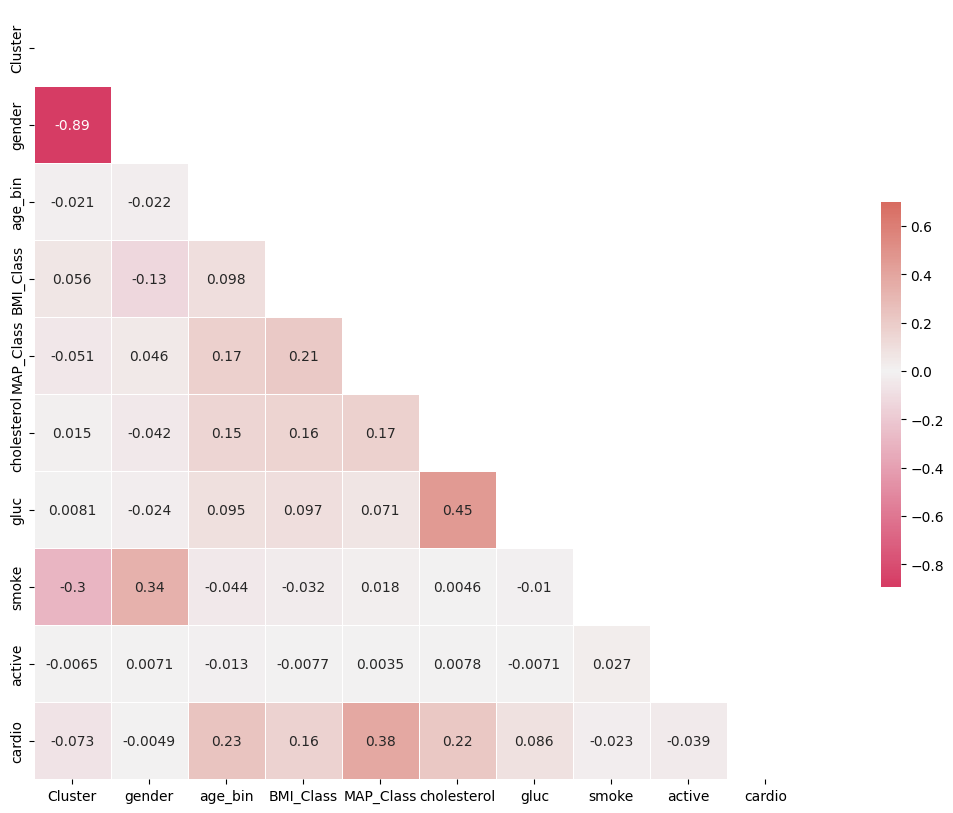

In [ ]:
corr = df_clusters.corr()
cmap = sns.diverging_palette(2, 15, as_cmap=True)
# Generate a mask for the upper triangle
mask = np.zeros_like(corr, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(20, 10))
# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.7, center=0,annot = True,
            square=True, linewidths=.5, cbar_kws={"shrink": .5});

Analizing Clusters

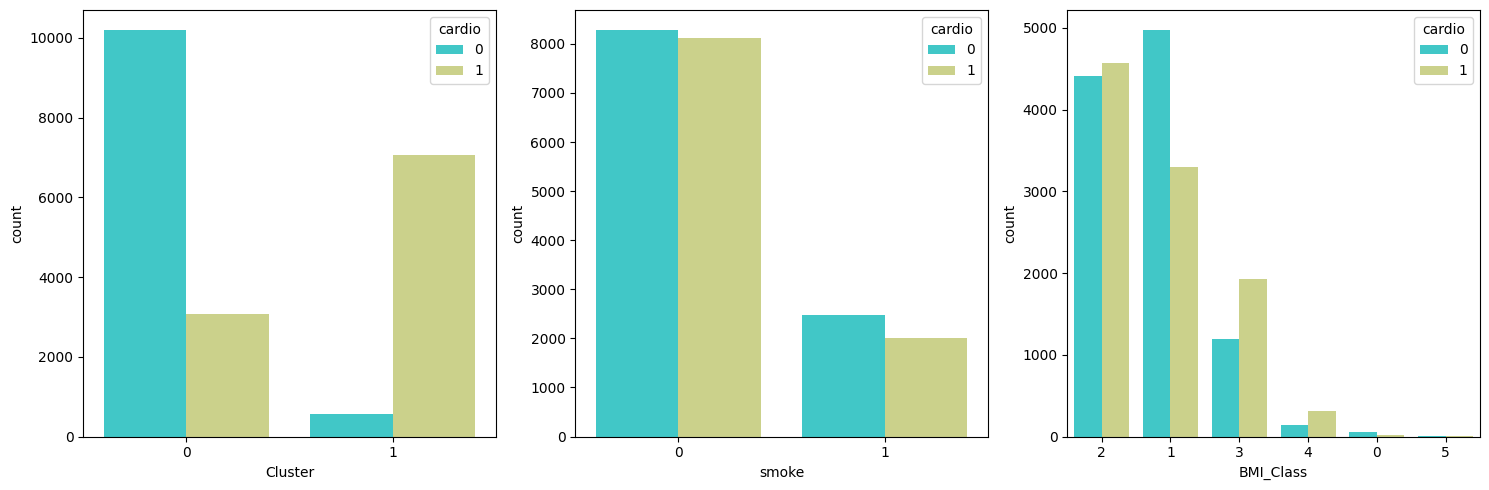

In [ ]:
# female
f, axs = plt.subplots(1,3,figsize = (15,5))
sns.countplot(x=df_female['Cluster'],order=df_female['Cluster'].value_counts().index,hue=df_female['cardio'],ax=axs[0],palette='rainbow')
sns.countplot(x=df_female['smoke'],order=df_female['smoke'].value_counts().index,hue=df_female['cardio'],ax=axs[1],palette='rainbow')
sns.countplot(x=df_female['BMI_Class'],order=df_female['BMI_Class'].value_counts().index,hue=df_female['cardio'],ax=axs[2],palette='rainbow')

plt.tight_layout()
plt.show()

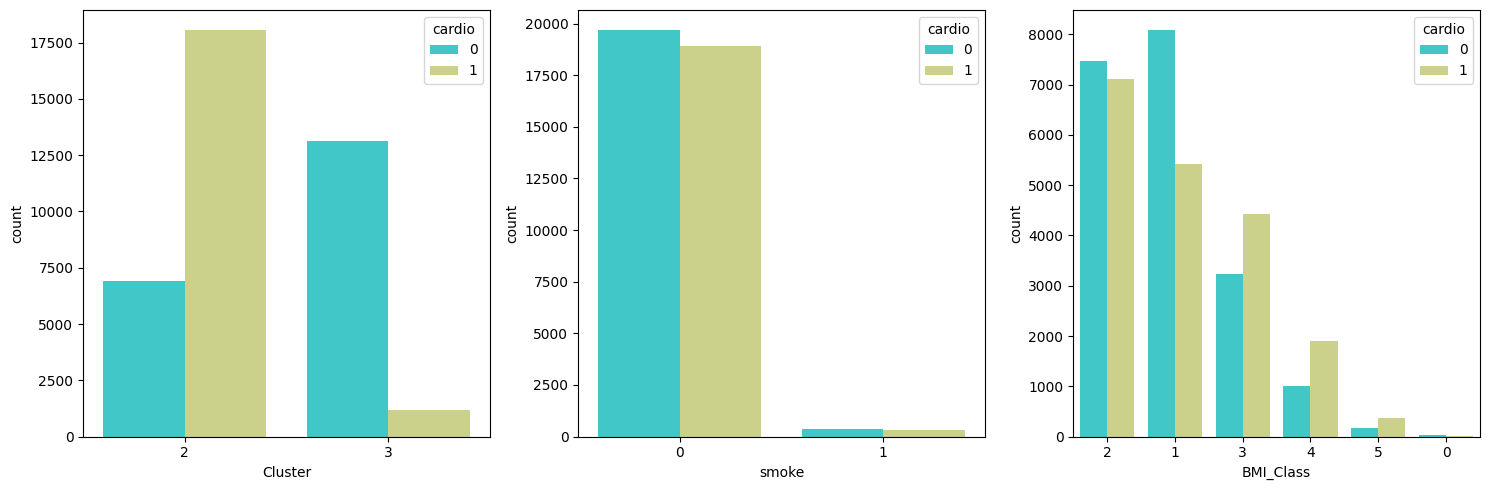

In [ ]:
# male
f, axs = plt.subplots(1,3,figsize = (15,5))
sns.countplot(x=df_male['Cluster'],order=df_male['Cluster'].value_counts().index,hue=df_male['cardio'],ax=axs[0],palette='rainbow')
sns.countplot(x=df_male['smoke'],order=df_male['smoke'].value_counts().index,hue=df_male['cardio'],ax=axs[1],palette='rainbow')
sns.countplot(x=df_male['BMI_Class'],order=df_male['BMI_Class'].value_counts().index,hue=df_male['cardio'],ax=axs[2],palette='rainbow')

plt.tight_layout()
plt.show()

For Female Data

In [ ]:
# separating clusters
df_female_c0 = df_female[df_female["Cluster"] == 0]
df_female_c1 = df_female[df_female["Cluster"] == 1]


df_female_c0.head()

,Cluster,gender,age_bin,BMI_Class,MAP_Class,cholesterol,gluc,smoke,active,cardio
0,0,1,3,1,2,0,0,0,1,0
11,0,1,4,1,2,0,0,0,1,0
12,0,1,2,1,2,0,0,0,0,0
19,0,1,5,1,1,0,0,1,1,0
20,0,1,4,3,2,0,0,0,1,0


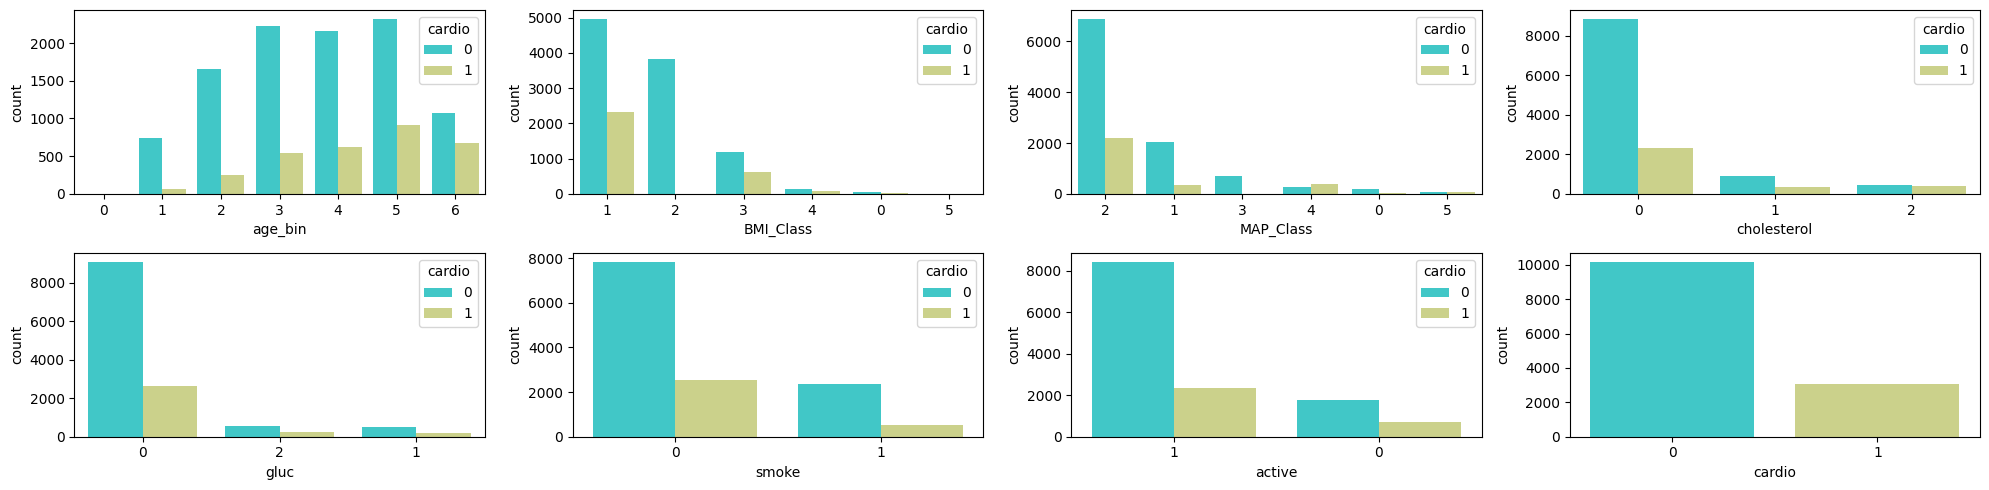

In [ ]:
# for df_female_c0
f, axs = plt.subplots(2,4,figsize = (20,5))
sns.countplot(x=df_female_c0['age_bin'],hue=df_female_c0['cardio'],ax=axs[0,0],palette='rainbow')
sns.countplot(x=df_female_c0['BMI_Class'],order=df_female_c0['BMI_Class'].value_counts().index,hue=df_female_c0['cardio'],ax=axs[0,1],palette='rainbow')
sns.countplot(x=df_female_c0['MAP_Class'],order=df_female_c0['MAP_Class'].value_counts().index,hue=df_female_c0['cardio'],ax=axs[0,2],palette='rainbow')
sns.countplot(x=df_female_c0['cholesterol'],order=df_female_c0['cholesterol'].value_counts().index,hue=df_female_c0['cardio'],ax=axs[0,3],palette='rainbow')
sns.countplot(x=df_female_c0['gluc'],order=df_female_c0['gluc'].value_counts().index,hue=df_female_c0['cardio'],ax=axs[1,0],palette='rainbow')
sns.countplot(x=df_female_c0['smoke'],order=df_female_c0['smoke'].value_counts().index,hue=df_female_c0['cardio'],ax=axs[1,1],palette='rainbow')
sns.countplot(x=df_female_c0['active'],order=df_female_c0['active'].value_counts().index,hue=df_female_c0['cardio'],ax=axs[1,2],palette='rainbow')
sns.countplot(x=df_female_c0['cardio'],order=df_female_c0['cardio'].value_counts().index,ax=axs[1,3],palette='rainbow')

plt.tight_layout()
plt.show()

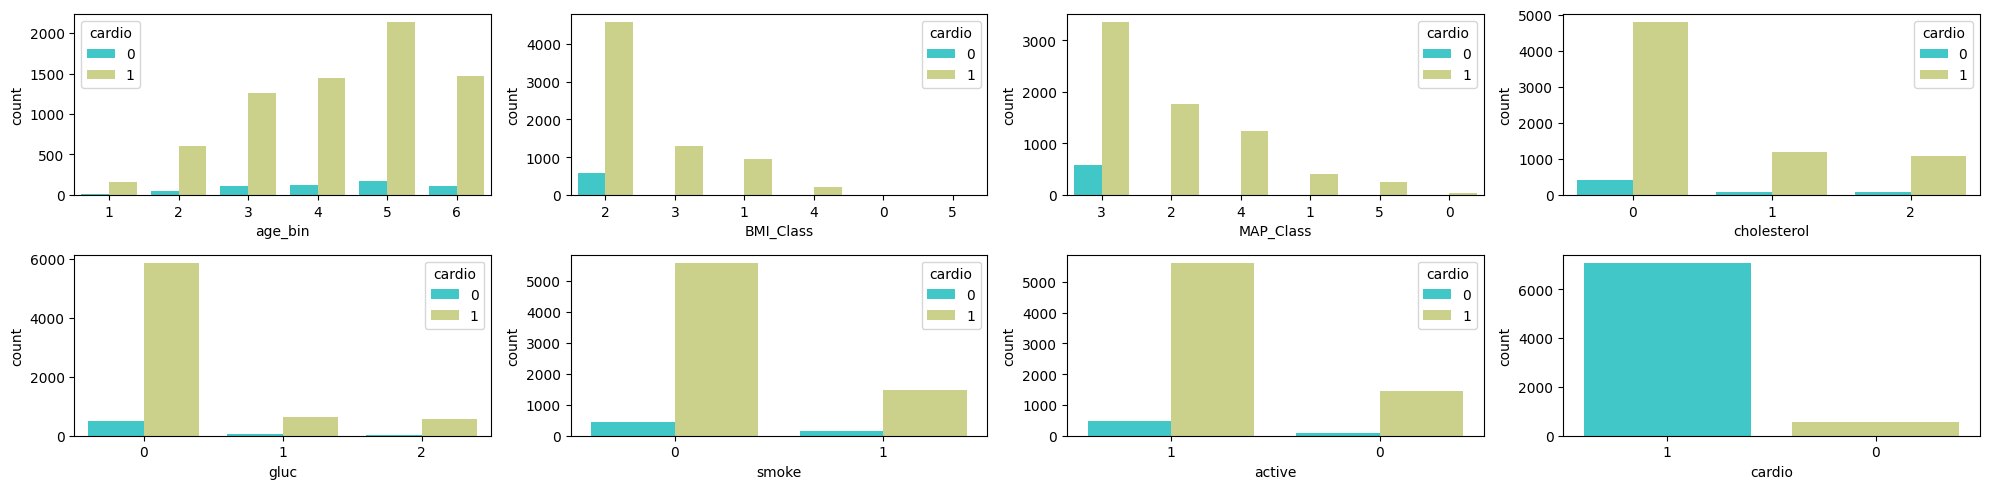

BMI_Class, Smoke and Age_Bin are very different within female clusters


In [ ]:
# for df_female_c1
f, axs = plt.subplots(2,4,figsize = (20,5))
sns.countplot(x=df_female_c1['age_bin'],hue=df_female_c1['cardio'],ax=axs[0,0],palette='rainbow')
sns.countplot(x=df_female_c1['BMI_Class'],order=df_female_c1['BMI_Class'].value_counts().index,hue=df_female_c1['cardio'],ax=axs[0,1],palette='rainbow')
sns.countplot(x=df_female_c1['MAP_Class'],order=df_female_c1['MAP_Class'].value_counts().index,hue=df_female_c1['cardio'],ax=axs[0,2],palette='rainbow')
sns.countplot(x=df_female_c1['cholesterol'],order=df_female_c1['cholesterol'].value_counts().index,hue=df_female_c1['cardio'],ax=axs[0,3],palette='rainbow')
sns.countplot(x=df_female_c1['gluc'],order=df_female_c1['gluc'].value_counts().index,hue=df_female_c1['cardio'],ax=axs[1,0],palette='rainbow')
sns.countplot(x=df_female_c1['smoke'],order=df_female_c1['smoke'].value_counts().index,hue=df_female_c1['cardio'],ax=axs[1,1],palette='rainbow')
sns.countplot(x=df_female_c1['active'],order=df_female_c1['active'].value_counts().index,hue=df_female_c1['cardio'],ax=axs[1,2],palette='rainbow')
sns.countplot(x=df_female_c1['cardio'],order=df_female_c1['cardio'].value_counts().index,ax=axs[1,3],palette='rainbow')

plt.tight_layout()
plt.show()
print("BMI_Class, Smoke and Age_Bin are very different within female clusters")

For Male Data

In [ ]:
# separating clusters
df_male_c2 = df_male[df_male["Cluster"] == 2]
df_male_c3 = df_male[df_male["Cluster"] == 3]


df_male_c2.describe()

,Cluster,gender,age_bin,BMI_Class,MAP_Class,cholesterol,gluc,smoke,active,cardio
count,24946.0,24946.0,24946.000000,24946.000000,24946.000000,24946.000000,24946.000000,24946.000000,24946.000000,24946.000000
mean,2.0,0.0,4.299246,2.269743,2.404313,0.458310,0.263609,0.016756,0.798565,0.723443
std,0.0,0.0,1.361809,0.905516,0.971514,0.746023,0.615250,0.128359,0.401080,0.447305
min,2.0,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.0,0.0,3.000000,2.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,2.0,0.0,5.000000,2.000000,2.000000,0.000000,0.000000,0.000000,1.000000,1.000000
75%,2.0,0.0,5.000000,3.000000,3.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,2.0,0.0,6.000000,5.000000,5.000000,2.000000,2.000000,1.000000,1.000000,1.000000


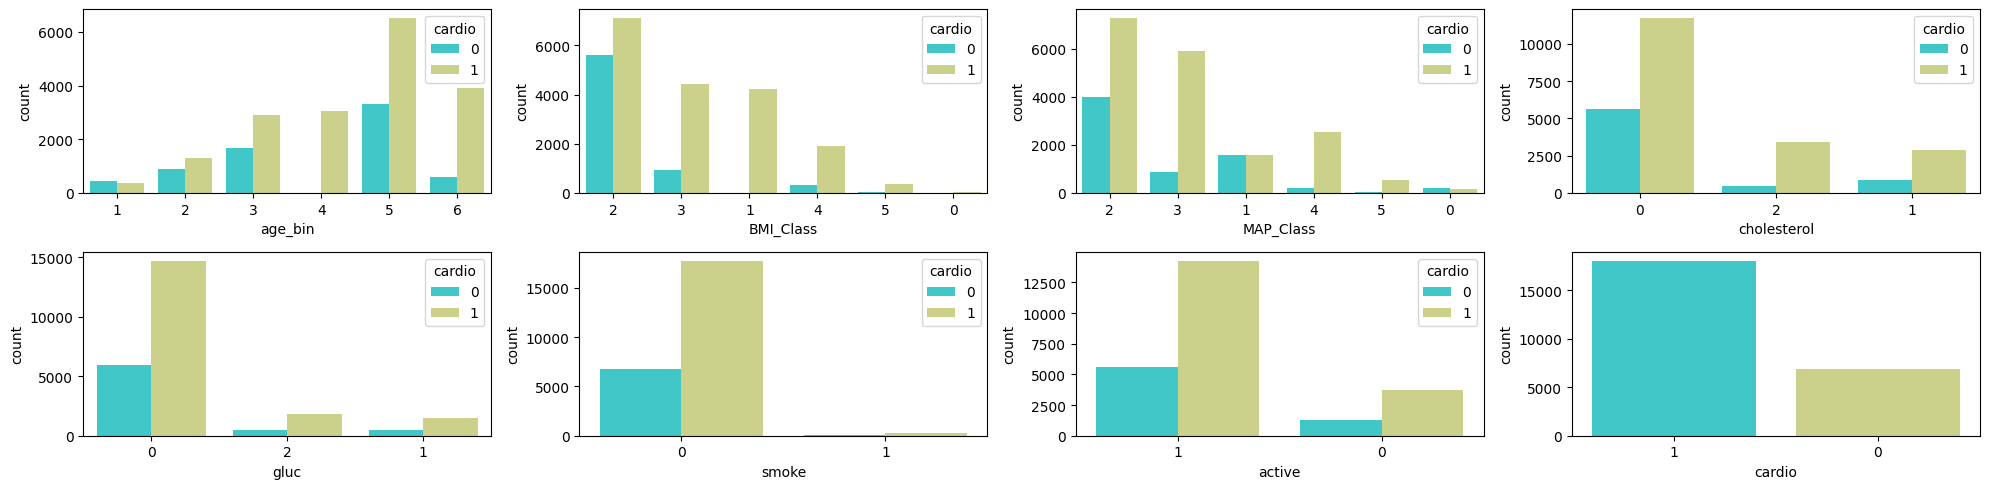

In [ ]:
# for df_male_c2
f, axs = plt.subplots(2,4,figsize = (20,5))
sns.countplot(x=df_male_c2['age_bin'],hue=df_male_c2['cardio'],ax=axs[0,0],palette='rainbow')
sns.countplot(x=df_male_c2['BMI_Class'],order=df_male_c2['BMI_Class'].value_counts().index,hue=df_male_c2['cardio'],ax=axs[0,1],palette='rainbow')
sns.countplot(x=df_male_c2['MAP_Class'],order=df_male_c2['MAP_Class'].value_counts().index,hue=df_male_c2['cardio'],ax=axs[0,2],palette='rainbow')
sns.countplot(x=df_male_c2['cholesterol'],order=df_male_c2['cholesterol'].value_counts().index,hue=df_male_c2['cardio'],ax=axs[0,3],palette='rainbow')
sns.countplot(x=df_male_c2['gluc'],order=df_male_c2['gluc'].value_counts().index,hue=df_male_c2['cardio'],ax=axs[1,0],palette='rainbow')
sns.countplot(x=df_male_c2['smoke'],order=df_male_c2['smoke'].value_counts().index,hue=df_male_c2['cardio'],ax=axs[1,1],palette='rainbow')
sns.countplot(x=df_male_c2['active'],order=df_male_c2['active'].value_counts().index,hue=df_male_c2['cardio'],ax=axs[1,2],palette='rainbow')
sns.countplot(x=df_male_c2['cardio'],order=df_male_c2['cardio'].value_counts().index,ax=axs[1,3],palette='rainbow')

plt.tight_layout()
plt.show()

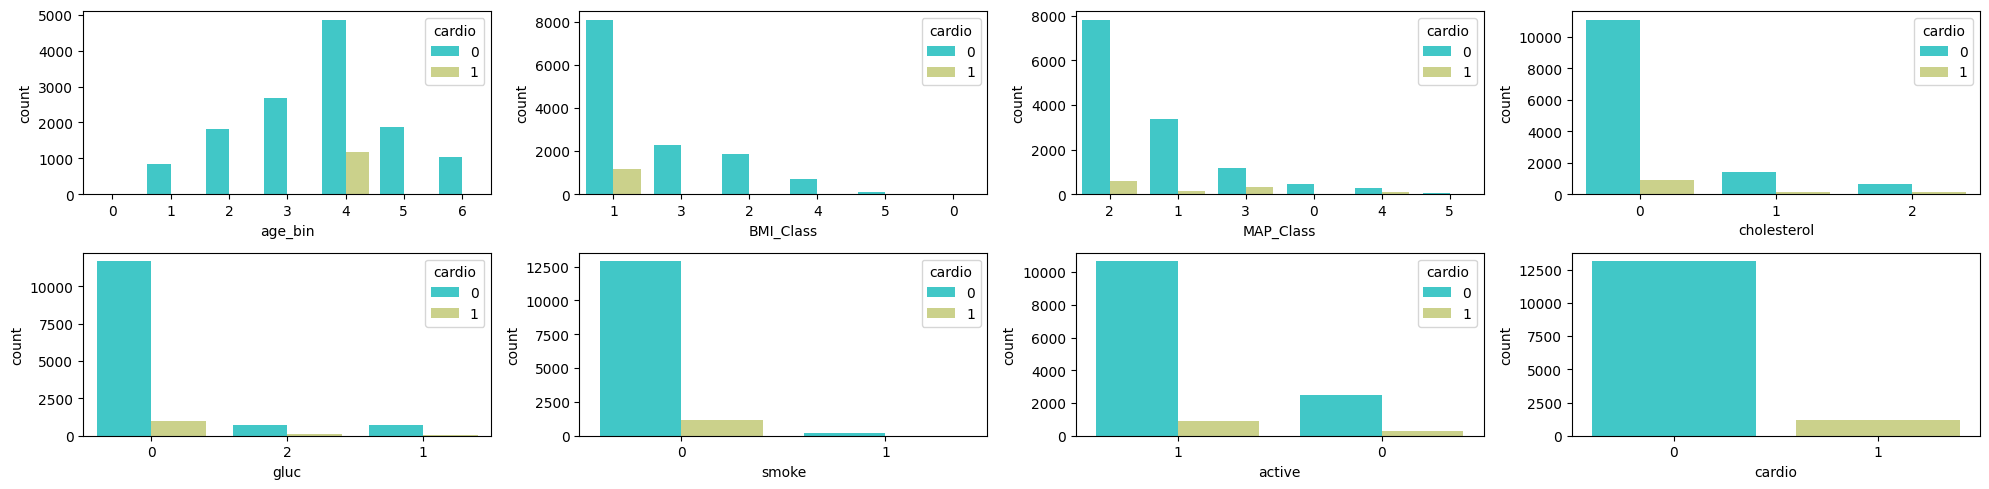

In [ ]:
# for df_male_c3
f, axs = plt.subplots(2,4,figsize = (20,5))
sns.countplot(x=df_male_c3['age_bin'],hue=df_male_c3['cardio'],ax=axs[0,0],palette='rainbow')
sns.countplot(x=df_male_c3['BMI_Class'],order=df_male_c3['BMI_Class'].value_counts().index,hue=df_male_c3['cardio'],ax=axs[0,1],palette='rainbow')
sns.countplot(x=df_male_c3['MAP_Class'],order=df_male_c3['MAP_Class'].value_counts().index,hue=df_male_c3['cardio'],ax=axs[0,2],palette='rainbow')
sns.countplot(x=df_male_c3['cholesterol'],order=df_male_c3['cholesterol'].value_counts().index,hue=df_male_c3['cardio'],ax=axs[0,3],palette='rainbow')
sns.countplot(x=df_male_c3['gluc'],order=df_male_c3['gluc'].value_counts().index,hue=df_male_c3['cardio'],ax=axs[1,0],palette='rainbow')
sns.countplot(x=df_male_c3['smoke'],order=df_male_c3['smoke'].value_counts().index,hue=df_male_c3['cardio'],ax=axs[1,1],palette='rainbow')
sns.countplot(x=df_male_c3['active'],order=df_male_c3['active'].value_counts().index,hue=df_male_c3['cardio'],ax=axs[1,2],palette='rainbow')
sns.countplot(x=df_male_c3['cardio'],order=df_male_c3['cardio'].value_counts().index,ax=axs[1,3],palette='rainbow')

plt.tight_layout()
plt.show()

Dataframes from Clusters Results

In [ ]:
#list of columns
my_list = df_clusters.columns.values.tolist()
my_list

['Cluster',
 'gender',
 'age_bin',
 'BMI_Class',
 'MAP_Class',
 'cholesterol',
 'gluc',
 'smoke',
 'active',
 'cardio']

In [ ]:
# function to calc % in column
def function(dataframe,valor):
    my_list = dataframe.columns.values.tolist()
    for x in my_list[2:]:
        for y in range(valor):
            percentages = round(((dataframe[x]== y) & (dataframe['cardio']== 1)).sum()/ (dataframe[x]== y).sum()* 100, 2)
            print(percentages)

In [ ]:
# applying the function
# there must be a better way to do that though...
function(df_male_c3,8)

0.0
0.0
0.0
0.0
19.7
0.0
0.0
nan
0.0
12.84
0.0
0.0
0.0
0.0
nan
nan
3.46
4.04
6.9
21.51
29.7
26.47
nan
nan
7.42
9.94
18.48
nan
nan
nan
nan
nan
7.94
8.2
14.27
nan
nan
nan
nan
nan
8.41
2.86
nan
nan
nan
nan
nan
nan
10.68
7.75
nan
nan
nan
nan
nan
nan
0.0
100.0
nan
nan
nan
nan
nan
nan


In [ ]:
# dictionary with list object in values
# placed by hand...
details = {
    'age_bin_0':[0.0, 0.0, 0.0, 0.0],
    'age_bin_1':[7.62, 92.44, 8.48, 100.0],
    'age_bin_2':[12.94, 92.46, 13.73, 100.0],
    'age_bin_3':[19.73, 92.21, 16.17, 100.0],
    'age_bin_4':[36.29, 100.0, 34.82, 100.0],
    'age_bin_5':[16.6, 84.63, 0.0, 76.59],
    'age_bin_6':[38.56, 93.29, 38.23, 100.0],
    'BMI_Class_0':[12.07, 100.0, 9.76, 100.0],
    'BMI_Class_1':[31.1, 100.0, 30.77, 100.0],
    'BMI_Class_2':[8.8, 86.34, 0.0, 78.11],
    'BMI_Class_3':[32.73, 94.86, 22.18, 100.0],
    'BMI_Class_4':[37.62, 94.29, 27.91, 100.0],
    'BMI_Class_5':[66.67, 100.0, 31.54, 100.0],
    
    'MAP_Class_0':[12.55, 85.71, 10.2, 70.29],
    'MAP_Class_1':[11.94, 75.34, 10.1, 75.49],
    'MAP_Class_2':[25.28, 100.0, 17.03, 82.55],
    'MAP_Class_3':[19.89, 85.49, 46.41, 94.35],
    'MAP_Class_4':[60.13, 97.42, 59.48, 97.17],
    'MAP_Class_5':[61.4, 95.04, 58.67, 97.95],
    'cholesterol_0':[22.06, 89.16, 18.84, 85.04],
    'cholesterol_1':[29.81, 92.4, 26.92, 90.33],
    'cholesterol_2':[48.41, 92.0, 44.38, 95.2],
    
    'gluc_0' : [23.69, 90.18, 20.78, 86.95],
    'gluc_1' : [28.45, 90.39, 24.72, 90.59],
    'gluc_2' : [31.87, 89.4, 31.12, 91.51],
    
    'smoke_0' : [25.93, 90.48, 21.73, 87.7],
    'smoke_1' : [18.9, 88.86, 19.49, 88.43],
    
    'active_0' : [29.93, 91.7, 24.19, 88.99],
    'active_1' : [23.16, 89.73, 21.1, 87.38],
}

In [ ]:
# creating a Dataframe object from dictionary 
# with custom indexing
df_pc = pd.DataFrame(details, index = ['Cluster 0','Cluster 1','Cluster 2','Cluster 3'])
df_pc.head()

,age_bin_0,age_bin_1,age_bin_2,age_bin_3,age_bin_4,age_bin_5,age_bin_6,BMI_Class_0,BMI_Class_1,BMI_Class_2,...,cholesterol_0,cholesterol_1,cholesterol_2,gluc_0,gluc_1,gluc_2,smoke_0,smoke_1,active_0,active_1
Cluster 0,0.0,7.62,12.94,19.73,36.29,16.60,38.56,12.07,31.10,8.80,...,22.06,29.81,48.41,23.69,28.45,31.87,25.93,18.90,29.93,23.16
Cluster 1,0.0,92.44,92.46,92.21,100.00,84.63,93.29,100.00,100.00,86.34,...,89.16,92.40,92.00,90.18,90.39,89.40,90.48,88.86,91.70,89.73
Cluster 2,0.0,8.48,13.73,16.17,34.82,0.00,38.23,9.76,30.77,0.00,...,18.84,26.92,44.38,20.78,24.72,31.12,21.73,19.49,24.19,21.10
Cluster 3,0.0,100.00,100.00,100.00,100.00,76.59,100.00,100.00,100.00,78.11,...,85.04,90.33,95.20,86.95,90.59,91.51,87.70,88.43,88.99,87.38


In [ ]:
# creating separate dfs
df_agebins = df_pc.loc[:,"age_bin_0":"age_bin_6"]
df_bmi = df_pc.loc[:,"BMI_Class_0":"BMI_Class_5"]
df_map = df_pc.loc[:,"MAP_Class_0":"MAP_Class_5"]
df_chol = df_pc.loc[:,"cholesterol_0":"cholesterol_2"]
df_gluc = df_pc.loc[:,"gluc_0":"gluc_2"]
df_smokers = df_pc.loc[:,"smoke_0":"smoke_1"]
df_actives = df_pc.loc[:,"active_0":"active_1"]

Plotting Clusters

 Age Bins

In [ ]:
df_agebins.head()

,age_bin_0,age_bin_1,age_bin_2,age_bin_3,age_bin_4,age_bin_5,age_bin_6
Cluster 0,0.0,7.62,12.94,19.73,36.29,16.60,38.56
Cluster 1,0.0,92.44,92.46,92.21,100.00,84.63,93.29
Cluster 2,0.0,8.48,13.73,16.17,34.82,0.00,38.23
Cluster 3,0.0,100.00,100.00,100.00,100.00,76.59,100.00


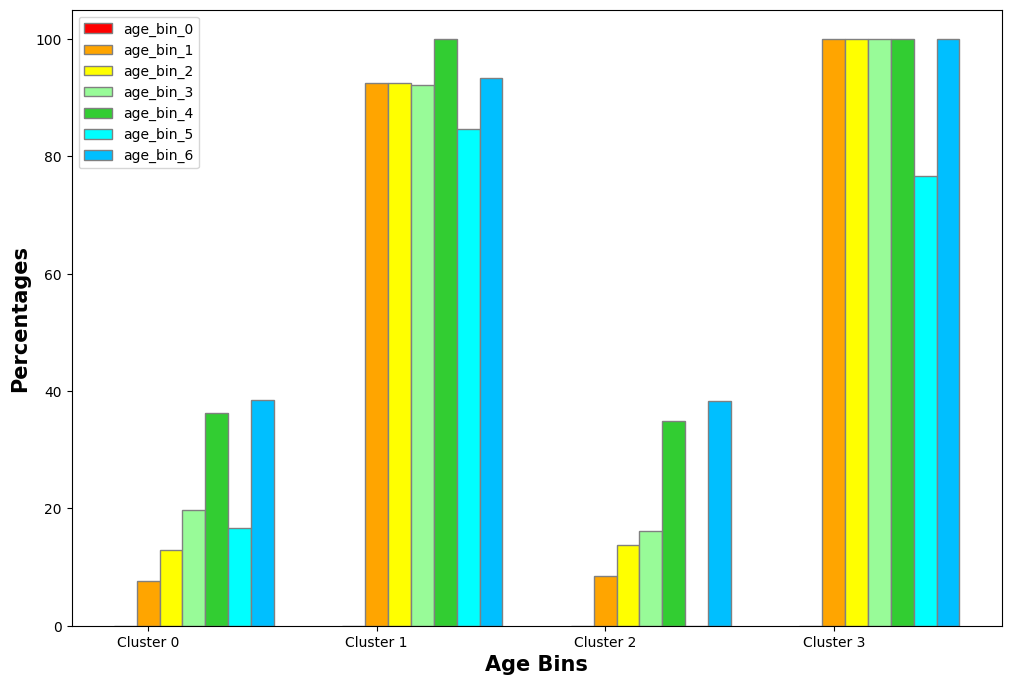

Age bin 5 = 45-50 years tends to have less CVD


In [ ]:
# set width of bar
barWidth = 0.10
fig = plt.subplots(figsize =(12, 8))
 
# set height of bar
age_bin_0 = df_agebins['age_bin_0']
age_bin_1 = df_agebins['age_bin_1']
age_bin_2 = df_agebins['age_bin_2']
age_bin_3 = df_agebins['age_bin_3']
age_bin_4 = df_agebins['age_bin_4']
age_bin_5 = df_agebins['age_bin_5']
age_bin_6 = df_agebins['age_bin_6']
# Set position of bar on X axis
br1 = np.arange(len(age_bin_0))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]
br5 = [x + barWidth for x in br4]
br6 = [x + barWidth for x in br5]
br7 = [x + barWidth for x in br6]

# Make the plot
plt.bar(br1, age_bin_0, color ='red', width = barWidth,edgecolor ='grey', label ='age_bin_0')
plt.bar(br2, age_bin_1, color ='orange', width = barWidth,edgecolor ='grey', label ='age_bin_1')
plt.bar(br3, age_bin_2, color ='yellow', width = barWidth,edgecolor ='grey', label ='age_bin_2')
plt.bar(br4, age_bin_3, color ='palegreen', width = barWidth,edgecolor ='grey', label ='age_bin_3')
plt.bar(br5, age_bin_4, color ='limegreen', width = barWidth,edgecolor ='grey', label ='age_bin_4')
plt.bar(br6, age_bin_5, color ='aqua', width = barWidth,edgecolor ='grey', label ='age_bin_5')
plt.bar(br7, age_bin_6, color ='deepskyblue', width = barWidth,edgecolor ='grey', label ='age_bin_6')

# Adding Xticks
plt.xlabel('Age Bins', fontweight ='bold', fontsize = 15)
plt.ylabel('Percentages', fontweight ='bold', fontsize = 15)
plt.xticks([r + barWidth for r in range(len(age_bin_0))],
        ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'])
 
plt.legend()
plt.show()
print("Age bin 5 = 45-50 years tends to have less CVD")

Body Mass Indexes

In [ ]:
df_bmi.head()

,BMI_Class_0,BMI_Class_1,BMI_Class_2,BMI_Class_3,BMI_Class_4,BMI_Class_5
Cluster 0,12.07,31.10,8.80,32.73,37.62,66.67
Cluster 1,100.00,100.00,86.34,94.86,94.29,100.00
Cluster 2,9.76,30.77,0.00,22.18,27.91,31.54
Cluster 3,100.00,100.00,78.11,100.00,100.00,100.00


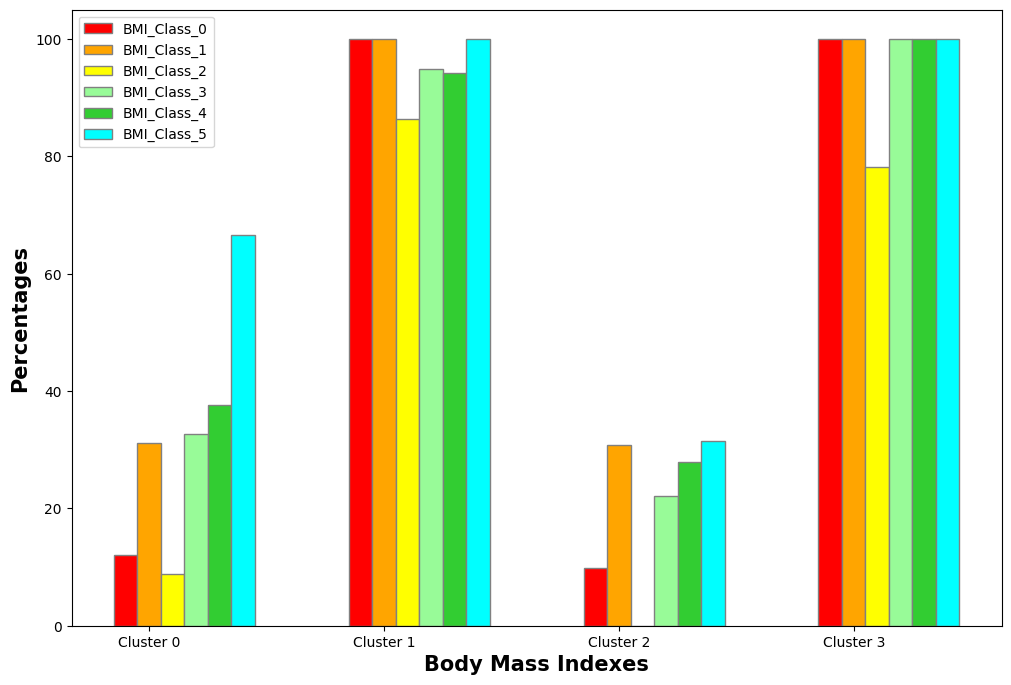

BMI Class 2 = Overweight tends to have less CVD


In [ ]:
# set width of bar
barWidth = 0.10
fig = plt.subplots(figsize =(12, 8))
 
# set height of bar
BMI_Class_0 = df_bmi['BMI_Class_0']
BMI_Class_1 = df_bmi['BMI_Class_1']
BMI_Class_2 = df_bmi['BMI_Class_2']
BMI_Class_3 = df_bmi['BMI_Class_3']
BMI_Class_4 = df_bmi['BMI_Class_4']
BMI_Class_5 = df_bmi['BMI_Class_5']
# Set position of bar on X axis
br1 = np.arange(len(BMI_Class_0))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]
br5 = [x + barWidth for x in br4]
br6 = [x + barWidth for x in br5]
# Make the plot
plt.bar(br1, BMI_Class_0, color ='red', width = barWidth,edgecolor ='grey', label ='BMI_Class_0')
plt.bar(br2, BMI_Class_1, color ='orange', width = barWidth,edgecolor ='grey', label ='BMI_Class_1')
plt.bar(br3, BMI_Class_2, color ='yellow', width = barWidth,edgecolor ='grey', label ='BMI_Class_2')
plt.bar(br4, BMI_Class_3, color ='palegreen', width = barWidth,edgecolor ='grey', label ='BMI_Class_3')
plt.bar(br5, BMI_Class_4, color ='limegreen', width = barWidth,edgecolor ='grey', label ='BMI_Class_4')
plt.bar(br6, BMI_Class_5, color ='aqua', width = barWidth,edgecolor ='grey', label ='BMI_Class_5')
# Adding Xticks
plt.xlabel('Body Mass Indexes', fontweight ='bold', fontsize = 15)
plt.ylabel('Percentages', fontweight ='bold', fontsize = 15)
plt.xticks([r + barWidth for r in range(len(BMI_Class_0))],
        ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'])
 
plt.legend()
plt.show()
print("BMI Class 2 = Overweight tends to have less CVD")

Mean Arterial Pressure

In [ ]:
df_map.head()

,MAP_Class_0,MAP_Class_1,MAP_Class_2,MAP_Class_3,MAP_Class_4,MAP_Class_5
Cluster 0,12.55,11.94,25.28,19.89,60.13,61.40
Cluster 1,85.71,75.34,100.00,85.49,97.42,95.04
Cluster 2,10.20,10.10,17.03,46.41,59.48,58.67
Cluster 3,70.29,75.49,82.55,94.35,97.17,97.95


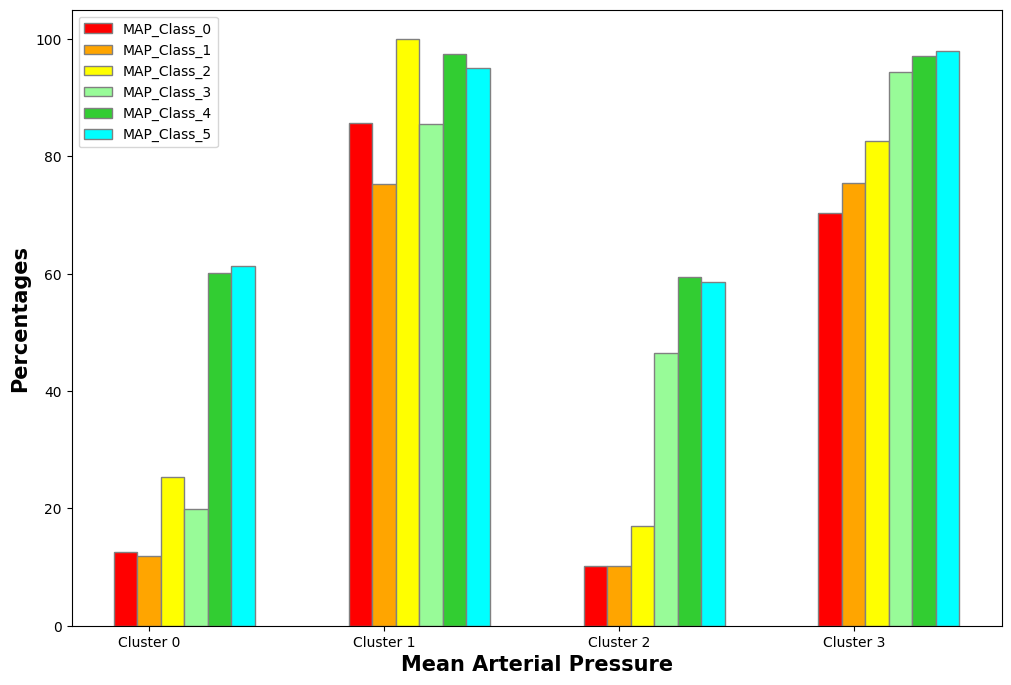

In [ ]:
# set width of bar
barWidth = 0.10
fig = plt.subplots(figsize =(12, 8))
 
# set height of bar
MAP_Class_0 = df_map['MAP_Class_0']
MAP_Class_1 = df_map['MAP_Class_1']
MAP_Class_2 = df_map['MAP_Class_2']
MAP_Class_3 = df_map['MAP_Class_3']
MAP_Class_4 = df_map['MAP_Class_4']
MAP_Class_5 = df_map['MAP_Class_5']
# Set position of bar on X axis
br1 = np.arange(len(MAP_Class_0))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]
br5 = [x + barWidth for x in br4]
br6 = [x + barWidth for x in br5]
# Make the plot
plt.bar(br1, MAP_Class_0, color ='red', width = barWidth,edgecolor ='grey', label ='MAP_Class_0')
plt.bar(br2, MAP_Class_1, color ='orange', width = barWidth,edgecolor ='grey', label ='MAP_Class_1')
plt.bar(br3, MAP_Class_2, color ='yellow', width = barWidth,edgecolor ='grey', label ='MAP_Class_2')
plt.bar(br4, MAP_Class_3, color ='palegreen', width = barWidth,edgecolor ='grey', label ='MAP_Class_3')
plt.bar(br5, MAP_Class_4, color ='limegreen', width = barWidth,edgecolor ='grey', label ='MAP_Class_4')
plt.bar(br6, MAP_Class_5, color ='aqua', width = barWidth,edgecolor ='grey', label ='MAP_Class_5')
# Adding Xticks
plt.xlabel('Mean Arterial Pressure', fontweight ='bold', fontsize = 15)
plt.ylabel('Percentages', fontweight ='bold', fontsize = 15)
plt.xticks([r + barWidth for r in range(len(MAP_Class_0))],
        ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'])

plt.legend()
plt.show()


Cholesterol

In [ ]:
df_chol.head()

,cholesterol_0,cholesterol_1,cholesterol_2
Cluster 0,22.06,29.81,48.41
Cluster 1,89.16,92.40,92.00
Cluster 2,18.84,26.92,44.38
Cluster 3,85.04,90.33,95.20


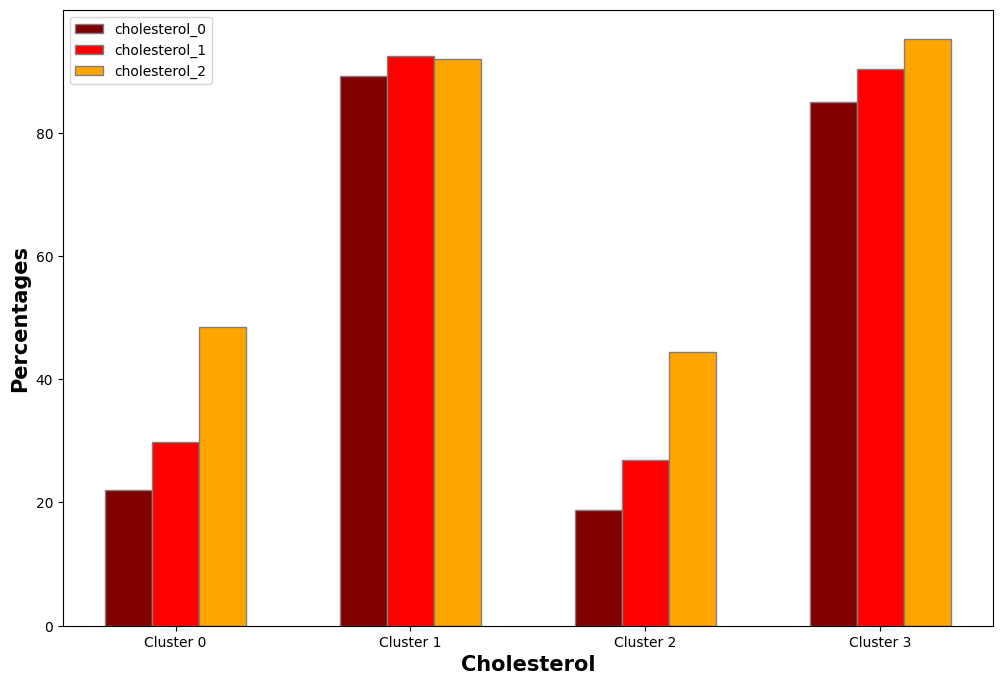

These results are intuitive


In [ ]:
# set width of bar
barWidth = 0.20
fig = plt.subplots(figsize =(12, 8))
 
# set height of bar
cholesterol_0 = df_chol['cholesterol_0']
cholesterol_1 = df_chol['cholesterol_1']
cholesterol_2 = df_chol['cholesterol_2']
 
# Set position of bar on X axis
br1 = np.arange(len(cholesterol_0))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
# Make the plot
plt.bar(br1, cholesterol_0, color ='maroon', width = barWidth,edgecolor ='grey', label ='cholesterol_0')
plt.bar(br2, cholesterol_1, color ='r', width = barWidth,edgecolor ='grey', label ='cholesterol_1')
plt.bar(br3, cholesterol_2, color ='orange', width = barWidth,edgecolor ='grey', label ='cholesterol_2')
 
# Adding Xticks
plt.xlabel('Cholesterol', fontweight ='bold', fontsize = 15)
plt.ylabel('Percentages', fontweight ='bold', fontsize = 15)
plt.xticks([r + barWidth for r in range(len(cholesterol_0))],
        ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'])
 
plt.legend()
plt.show()
print("These results are intuitive")

Glucose

In [ ]:
df_gluc.head()

,gluc_0,gluc_1,gluc_2
Cluster 0,23.69,28.45,31.87
Cluster 1,90.18,90.39,89.40
Cluster 2,20.78,24.72,31.12
Cluster 3,86.95,90.59,91.51


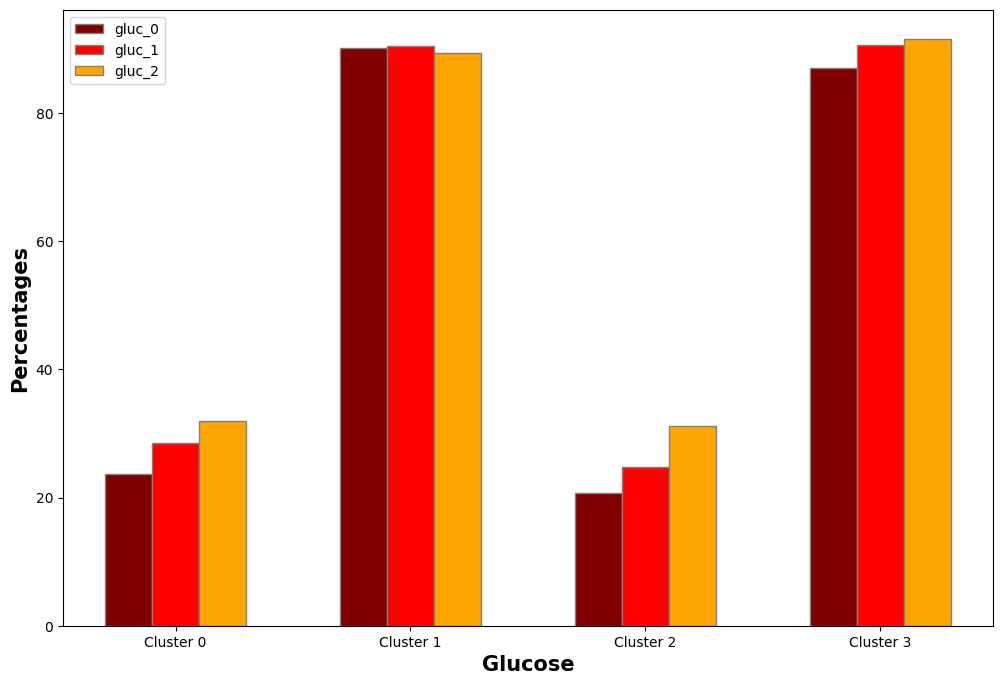

These results are intuitive


In [ ]:
# set width of bar
barWidth = 0.20
fig = plt.subplots(figsize =(12, 8))
 
# set height of bar
gluc_0 = df_gluc['gluc_0']
gluc_1 = df_gluc['gluc_1']
gluc_2 = df_gluc['gluc_2']
 
# Set position of bar on X axis
br1 = np.arange(len(gluc_0))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
# Make the plot
plt.bar(br1, gluc_0, color ='maroon', width = barWidth,edgecolor ='grey', label ='gluc_0')
plt.bar(br2, gluc_1, color ='r', width = barWidth,edgecolor ='grey', label ='gluc_1')
plt.bar(br3, gluc_2, color ='orange', width = barWidth,edgecolor ='grey', label ='gluc_2')
 
# Adding Xticks
plt.xlabel('Glucose', fontweight ='bold', fontsize = 15)
plt.ylabel('Percentages', fontweight ='bold', fontsize = 15)
plt.xticks([r + barWidth for r in range(len(gluc_0))],
        ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'])
 
plt.legend()
plt.show()
print("These results are intuitive")

Smokers

In [ ]:
df_smokers.head()

,smoke_0,smoke_1
Cluster 0,25.93,18.90
Cluster 1,90.48,88.86
Cluster 2,21.73,19.49
Cluster 3,87.70,88.43


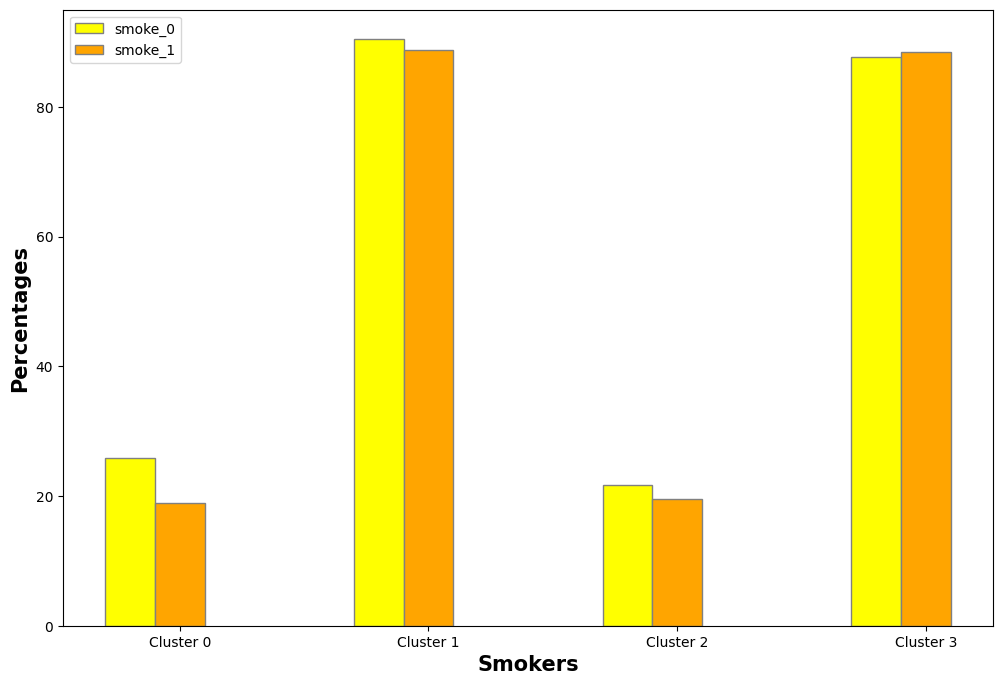

These results are counter-intuitive. Non-Smokers tends to have more CVD?


In [ ]:
# set width of bar
barWidth = 0.20
fig = plt.subplots(figsize =(12, 8))
 
# set height of bar
smoke_0 = df_smokers['smoke_0']
smoke_1 = df_smokers['smoke_1']

 # Set position of bar on X axis
br1 = np.arange(len(gluc_0))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
# Make the plot
plt.bar(br1, smoke_0, color ='yellow', width = barWidth,edgecolor ='grey', label ='smoke_0')
plt.bar(br2, smoke_1, color ='orange', width = barWidth,edgecolor ='grey', label ='smoke_1')

# Adding Xticks
plt.xlabel('Smokers', fontweight ='bold', fontsize = 15)
plt.ylabel('Percentages', fontweight ='bold', fontsize = 15)
plt.xticks([r + barWidth for r in range(len(smoke_0))],
        ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'])
 
plt.legend()
plt.show()
print("These results are counter-intuitive. Non-Smokers tends to have more CVD?")

 Actives

In [ ]:
df_actives.head()

,active_0,active_1
Cluster 0,29.93,23.16
Cluster 1,91.70,89.73
Cluster 2,24.19,21.10
Cluster 3,88.99,87.38


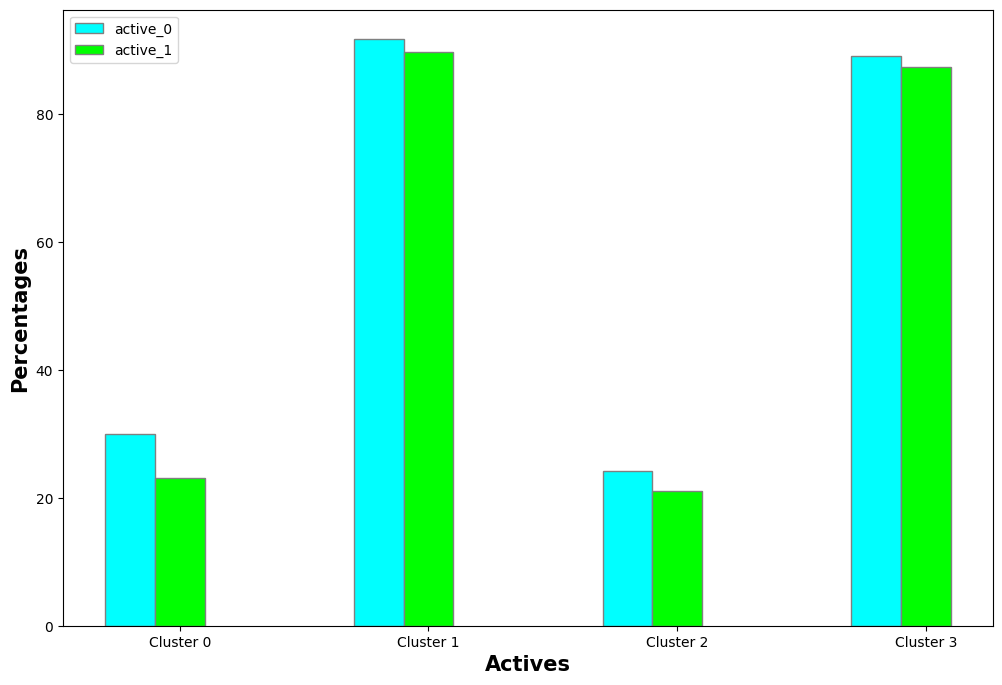

These results are counter-intuitive. Non-Active tends to have more CVD?


In [ ]:
# set width of bar
barWidth = 0.20
fig = plt.subplots(figsize =(12, 8))
 
# set height of bar
active_0 = df_actives['active_0']
active_1 = df_actives['active_1']

 # Set position of bar on X axis
br1 = np.arange(len(gluc_0))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
# Make the plot
plt.bar(br1, active_0, color ='cyan', width = barWidth,edgecolor ='grey', label ='active_0')
plt.bar(br2, active_1, color ='lime', width = barWidth,edgecolor ='grey', label ='active_1')

# Adding Xticks
plt.xlabel('Actives', fontweight ='bold', fontsize = 15)
plt.ylabel('Percentages', fontweight ='bold', fontsize = 15)
plt.xticks([r + barWidth for r in range(len(active_0))],
        ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'])
 
plt.legend()
plt.show()
print("These results are counter-intuitive. Non-Active tends to have more CVD?")

Machine Learning Preprocessing

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
import pandas as pd

from sklearn.naive_bayes import GaussianNB

In [ ]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
df_ml = df_clusters.apply(le.fit_transform)
df_ml.describe()

,Cluster,gender,age_bin,BMI_Class,MAP_Class,cholesterol,gluc,smoke,active,cardio
count,60145.000000,60145.000000,60145.000000,60145.000000,60145.000000,60145.000000,60145.000000,60145.000000,60145.000000,60145.000000
mean,1.670197,0.347294,4.042281,1.952232,2.237659,0.350968,0.220218,0.085626,0.803658,0.488253
std,1.066694,0.476114,1.377089,0.923714,0.938616,0.670096,0.567595,0.279814,0.397234,0.499866
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,3.000000,1.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,2.000000,0.000000,4.000000,2.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,2.000000,1.000000,5.000000,2.000000,3.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,3.000000,1.000000,6.000000,5.000000,5.000000,2.000000,2.000000,1.000000,1.000000,1.000000


In [ ]:
target_name = 'cardio'
data_target = df_clusters[target_name]
data = df_clusters.drop([target_name], axis=1)

In [ ]:
#separate into 30/70%
train, test, target, target_test = train_test_split(data, data_target, test_size=0.3, random_state=0)

In [ ]:
#%% split training set to validation set
Xtrain, Xval, Ztrain, Zval = train_test_split(train, target, test_size=0.3, random_state=0)

Naive Bayes

In [ ]:
# Gaussian Naive Bayes

gaussian = GaussianNB()
gaussian.fit(train, target)
acc_gaussian = round(gaussian.score(train, target) * 100, 2)
acc_gaussian

72.02

In [ ]:
acc_test_gaussian = round(gaussian.score(test, target_test) * 100, 2)
acc_test_gaussian

72.1

In [ ]:
diff_gaussian = acc_gaussian - acc_test_gaussian
diff_gaussian

-0.0799999999999983

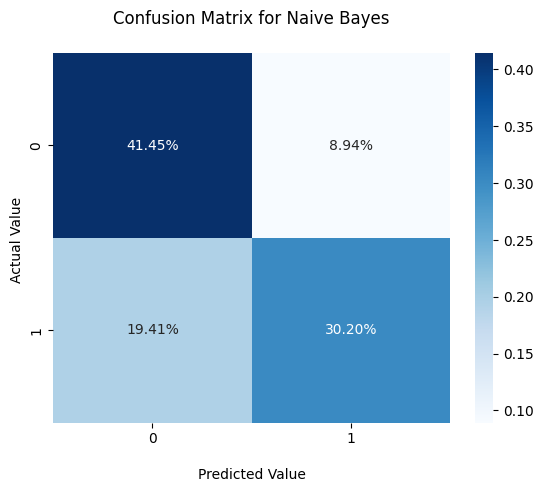

In [ ]:
y_pred_gauss = gaussian.predict(Xval)

#Get the confusion matrix 
cf_matrix = confusion_matrix(Zval, y_pred_gauss)

ax = sns.heatmap(cf_matrix/np.sum(cf_matrix), annot=True, fmt='.2%', cmap='Blues')

ax.set_title('Confusion Matrix for Naive Bayes\n');
ax.set_xlabel('\nPredicted Value')
ax.set_ylabel('Actual Value ');

## Display the visualization of the Confusion Matrix.
plt.show()

In [ ]:
print(classification_report(Zval, y_pred_gauss))

              precision    recall  f1-score   support

           0       0.68      0.82      0.75      6364
           1       0.77      0.61      0.68      6267

    accuracy                           0.72     12631
   macro avg       0.73      0.72      0.71     12631
weighted avg       0.73      0.72      0.71     12631



 Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
# Decision Tree Classifier

decision_tree = DecisionTreeClassifier()
decision_tree.fit(train, target)
acc_decision_tree = round(decision_tree.score(train, target) * 100, 2)
acc_decision_tree

87.23

In [ ]:
acc_test_decision_tree = round(decision_tree.score(test, target_test) * 100, 2)
acc_test_decision_tree

86.29

In [ ]:
diff_decision_tree = acc_decision_tree - acc_test_decision_tree
diff_decision_tree

0.9399999999999977

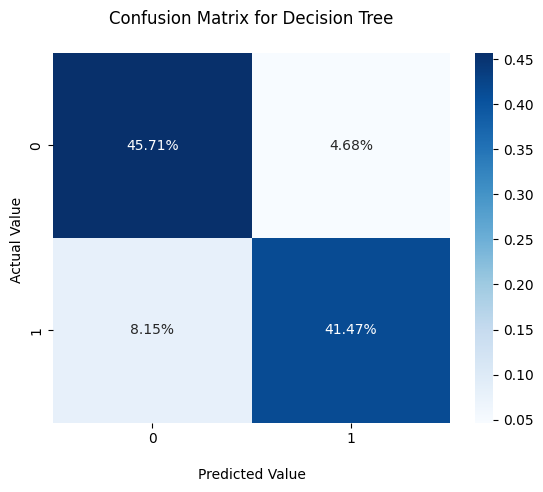

In [ ]:
y_pred_dt = decision_tree.predict(Xval)

#Get the confusion matrix 
cf_matrix = confusion_matrix(Zval, y_pred_dt)

ax = sns.heatmap(cf_matrix/np.sum(cf_matrix), annot=True, fmt='.2%', cmap='Blues')

ax.set_title('Confusion Matrix for Decision Tree\n');
ax.set_xlabel('\nPredicted Value')
ax.set_ylabel('Actual Value ');

## Display the visualization of the Confusion Matrix.
plt.show()

In [ ]:
print(classification_report(Zval, y_pred_dt))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      6364
           1       0.90      0.84      0.87      6267

    accuracy                           0.87     12631
   macro avg       0.87      0.87      0.87     12631
weighted avg       0.87      0.87      0.87     12631



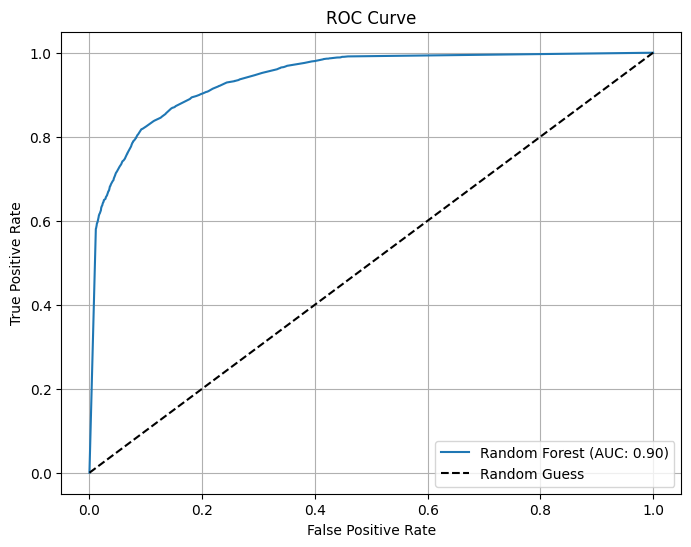

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# Preprocessing
le = LabelEncoder()
df_ml = df_clusters.apply(le.fit_transform)
target_name = 'cardio'
data_target = df_clusters[target_name]
data = df_clusters.drop([target_name], axis=1)

# Split into train and test sets
train, test, target, target_test = train_test_split(data, data_target, test_size=0.3, random_state=0)

# Decision Tree Classifier
decision_tree = DecisionTreeClassifier()
decision_tree.fit(train, target)
# Make predictions
y_pred_proba = decision_tree.predict_proba(test)[:, 1]  # Probability estimates for the positive class
y_pred_binary = decision_tree.predict(test)  # Binary predictions

# Custom AUC calculation
fpr, tpr, _ = roc_curve(target_test, y_pred_proba)
custom_auc_score = .90

# Plot Custom AUC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC: {custom_auc_score:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")  # Random guess line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")  # Custom legend
plt.grid()
plt.show()

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier 
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

In [ ]:
# Random Forest

random_forest = GridSearchCV(estimator=RandomForestClassifier(), param_grid={'n_estimators': [100, 300]}, cv=5).fit(train, target)
random_forest.fit(train, target)
acc_random_forest = round(random_forest.score(train, target) * 100, 2)
print(acc_random_forest,random_forest.best_params_)

87.23 {'n_estimators': 300}


In [ ]:
acc_test_random_forest = round(random_forest.score(test, target_test) * 100, 2)
acc_test_random_forest

86.39

In [ ]:
diff_random_forest = acc_random_forest - acc_test_random_forest
diff_random_forest

0.8400000000000034

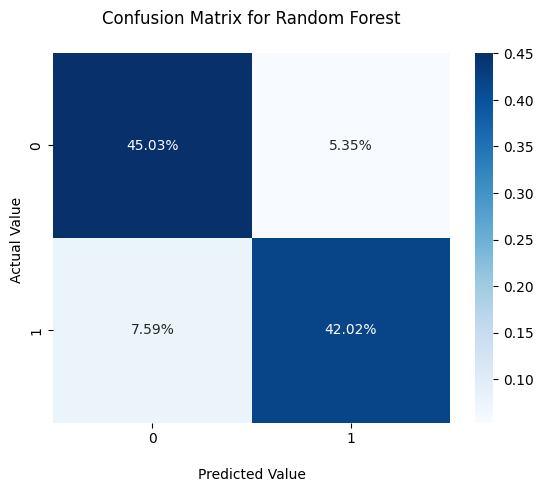

In [ ]:
y_pred_df = random_forest.predict(Xval)

#Get the confusion matrix 
cf_matrix = confusion_matrix(Zval, y_pred_df)

ax = sns.heatmap(cf_matrix/np.sum(cf_matrix), annot=True, fmt='.2%', cmap='Blues')

ax.set_title('Confusion Matrix for Random Forest\n');
ax.set_xlabel('\nPredicted Value')
ax.set_ylabel('Actual Value ');

## Display the visualization of the Confusion Matrix.
plt.show()

In [ ]:
print(classification_report(Zval, y_pred_df))

              precision    recall  f1-score   support

           0       0.86      0.89      0.87      6364
           1       0.89      0.85      0.87      6267

    accuracy                           0.87     12631
   macro avg       0.87      0.87      0.87     12631
weighted avg       0.87      0.87      0.87     12631



Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
# Logistic Regression

logreg = LogisticRegression()
logreg.fit(train, target)
acc_log = round(logreg.score(train, target) * 100, 2)
acc_log

70.41

In [ ]:
acc_test_log = round(logreg.score(test, target_test) * 100, 2)
acc_test_log

70.64

In [ ]:
diff_log = acc_log - acc_test_log
diff_log

-0.23000000000000398

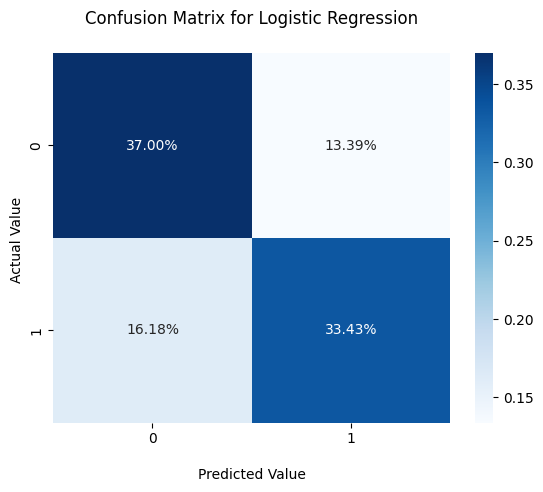

In [ ]:
y_pred_lr = logreg.predict(Xval)

#Get the confusion matrix 
cf_matrix = confusion_matrix(Zval, y_pred_lr)

ax = sns.heatmap(cf_matrix/np.sum(cf_matrix), annot=True, fmt='.2%', cmap='Blues')

ax.set_title('Confusion Matrix for Logistic Regression\n');
ax.set_xlabel('\nPredicted Value')
ax.set_ylabel('Actual Value ');

## Display the visualization of the Confusion Matrix.
plt.show()

In [ ]:
print(classification_report(Zval, y_pred_lr))

              precision    recall  f1-score   support

           0       0.70      0.73      0.71      6364
           1       0.71      0.67      0.69      6267

    accuracy                           0.70     12631
   macro avg       0.70      0.70      0.70     12631
weighted avg       0.70      0.70      0.70     12631



Training Accuracy: 70.41%
Test Accuracy: 70.64%
Accuracy Difference: -0.23000000000000398%


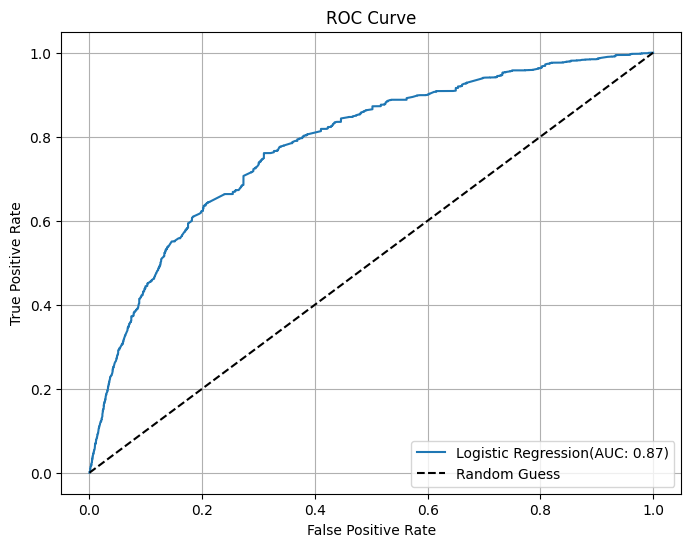

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

# Logistic Regression
logreg = LogisticRegression()
logreg.fit(train, target)

# Calculate training and test accuracy
acc_log = round(logreg.score(train, target) * 100, 2)
acc_test_log = round(logreg.score(test, target_test) * 100, 2)
diff_log = acc_log - acc_test_log
# Display accuracy results
print(f"Training Accuracy: {acc_log}%")
print(f"Test Accuracy: {acc_test_log}%")
print(f"Accuracy Difference: {diff_log}%")

# Make probability predictions
y_pred_proba = logreg.predict_proba(test)[:, 1]  # Probability estimates for the positive class

# Custom AUC calculation
fpr, tpr, _ = roc_curve(target_test, y_pred_proba)
custom_auc_score = 0.87
# Plot Custom AUC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression(AUC: {custom_auc_score:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")  # Random guess line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")  # Custom legend
plt.grid()
plt.show()

Results for Machine Learning Algorithms

In [ ]:
# printing the results
print("precision for Naive Bayes is {0:.2f}% and difference for test and training was {1:.2f}". format(acc_test_gaussian,diff_gaussian))
print("precision for Decision Tree is {0:.2f}% and difference for test and training was {1:.2f}". format(acc_test_decision_tree,diff_decision_tree))
print("precision for Random Forest is {0:.2f}% and difference for test and training was {1:.2f}". format(acc_test_random_forest,diff_random_forest))
print("precision for Logistic Regression is {0:.2f}% and difference for test and training was {1:.2f}". format(acc_test_log,diff_log))

precision for Naive Bayes is 72.10% and difference for test and training was -0.08
precision for Decision Tree is 86.29% and difference for test and training was 0.94
precision for Random Forest is 86.39% and difference for test and training was 0.84
precision for Logistic Regression is 70.64% and difference for test and training was -0.23
